In [5]:
import pandas as pd

file_path = "cleaned_atm_2025.csv"

df = pd.read_csv(file_path)

print("=" * 90)
print("ATM EXPLORATORY DATA ANALYSIS")
print("=" * 90)

print(f"\nInput file : {file_path}")
print(f"Rows       : {df.shape[0]}")
print(f"Columns    : {df.shape[1]}")

print("\n✓ ATM dataset loaded successfully.")

ATM EXPLORATORY DATA ANALYSIS

Input file : cleaned_atm_2025.csv
Rows       : 768
Columns    : 35

✓ ATM dataset loaded successfully.


In [6]:
print("=" * 90)
print("DATASET STRUCTURE & DATA TYPES")
print("=" * 90)

print("\nDATASET SHAPE")
print("-" * 90)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nCOLUMN NAMES")
print("-" * 90)
for i, col in enumerate(df.columns, start=1):
    print(f"{i:2}. {col}")

print("\nDATA TYPES")
print("-" * 90)
print(df.dtypes)

print("\nDATASET INFO")
print("-" * 90)
df.info()

print("\n✓ Dataset structure and data type inspection completed.")

DATASET STRUCTURE & DATA TYPES

DATASET SHAPE
------------------------------------------------------------------------------------------
Rows    : 768
Columns : 35

COLUMN NAMES
------------------------------------------------------------------------------------------
 1. Year
 2. Month
 3. Quarter
 4. Source File
 5. Sr. No.
 6. Bank Name
 7. Bank Category
 8. Infrastructure - ATMs & CRMs - On-site
 9. Infrastructure - ATMs & CRMs - Off-site
10. Infrastructure - PoS
11. Infrastructure - Micro ATMs
12. Infrastructure - Bharat QR Codes
13. Infrastructure - UPI QR Codes
14. Infrastructure - Credit Cards
15. Infrastructure - Debit Cards
16. Credit Card - Card Payments - PoS - Volume (in actuals)
17. Credit Card - Card Payments - PoS - Value (in Rs'000)
18. Credit Card - Card Payments - Online (e-com) - Volume (in actuals)
19. Credit Card - Card Payments - Online (e-com) - Value (in Rs'000)
20. Credit Card - Card Payments - Others - Volume (in actuals)
21. Credit Card - Card Payments - Oth

In [7]:
print("=" * 90)
print("MISSING VALUE ANALYSIS")
print("=" * 90)

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percent
})

missing_summary = missing_summary[missing_summary["Missing_Count"] > 0]

print("\nMISSING VALUES BY COLUMN")
print("-" * 90)

if missing_summary.empty:
    print("✓ No missing values found in the dataset.")
else:
    print(missing_summary.to_string())

print("\nTOTAL MISSING VALUES")
print("-" * 90)
print(f"Total missing cells : {df.isnull().sum().sum()}")

print("\nCOMPLETE RECORDS")
print("-" * 90)
print(f"Complete rows : {df.dropna().shape[0]}")
print(f"Rows with missing values : {df.isnull().any(axis=1).sum()}")

print("\n✓ Missing value analysis completed.")

MISSING VALUE ANALYSIS

MISSING VALUES BY COLUMN
------------------------------------------------------------------------------------------
✓ No missing values found in the dataset.

TOTAL MISSING VALUES
------------------------------------------------------------------------------------------
Total missing cells : 0

COMPLETE RECORDS
------------------------------------------------------------------------------------------
Complete rows : 768
Rows with missing values : 0

✓ Missing value analysis completed.


In [8]:
print("=" * 90)
print("DUPLICATE RECORD ANALYSIS")
print("=" * 90)

duplicate_rows = df.duplicated().sum()

print("\nDUPLICATE RECORDS")
print("-" * 90)
print(f"Total duplicate rows : {duplicate_rows}")

print("\nUNIQUE RECORDS")
print("-" * 90)
print(f"Unique rows : {df.drop_duplicates().shape[0]}")

print("\nDUPLICATE PERCENTAGE")
print("-" * 90)
print(f"Duplicate percentage : {(duplicate_rows / len(df)) * 100:.2f}%")

if duplicate_rows == 0:
    print("\n✓ No duplicate records found.")
else:
    print("\n⚠ Duplicate records detected.")

print("\n✓ Duplicate record analysis completed.")

DUPLICATE RECORD ANALYSIS

DUPLICATE RECORDS
------------------------------------------------------------------------------------------
Total duplicate rows : 0

UNIQUE RECORDS
------------------------------------------------------------------------------------------
Unique rows : 768

DUPLICATE PERCENTAGE
------------------------------------------------------------------------------------------
Duplicate percentage : 0.00%

✓ No duplicate records found.

✓ Duplicate record analysis completed.


In [9]:
categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns

print("=" * 90)
print("CATEGORICAL VARIABLE ANALYSIS")
print("=" * 90)

print("\nCATEGORICAL COLUMNS")
print("-" * 90)
for i, col in enumerate(categorical_columns, start=1):
    print(f"{i}. {col}")

print("\nUNIQUE VALUES")
print("-" * 90)
for col in categorical_columns:
    print(f"{col} : {df[col].nunique()} unique values")

print("\nVALUE COUNTS")
print("-" * 90)
for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts().to_string())

print("\n✓ Categorical variable analysis completed.")

CATEGORICAL VARIABLE ANALYSIS

CATEGORICAL COLUMNS
------------------------------------------------------------------------------------------
1. Month
2. Quarter
3. Source File
4. Bank Name
5. Bank Category
6. Date

UNIQUE VALUES
------------------------------------------------------------------------------------------
Month : 12 unique values
Quarter : 4 unique values
Source File : 12 unique values
Bank Name : 65 unique values
Bank Category : 5 unique values
Date : 12 unique values

VALUE COUNTS
------------------------------------------------------------------------------------------

Month
Month
January      64
February     64
March        64
April        64
May          64
June         64
July         64
August       64
September    64
October      64
November     64
December     64

Quarter
Quarter
Q1    192
Q2    192
Q3    192
Q4    192

Source File
Source File
ATMJANUARY2025B1FB692B5934404B883922E995D5FDD4.XLSX      64
ATMFEBRUARY20257E29C21AB6AD4CDFAB6C02CE146FC553.XLSX     64


In [10]:
# =============================================================================
# NUMERICAL VARIABLE ANALYSIS
# =============================================================================

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("=" * 90)
print("NUMERICAL VARIABLE ANALYSIS")
print("=" * 90)

print("\nNUMERICAL COLUMNS")
print("-" * 90)

for i, col in enumerate(numeric_columns, start=1):
    print(f"{i:2}. {col}")

print("\nNUMERICAL COLUMN COUNT")
print("-" * 90)
print(f"Numerical columns : {len(numeric_columns)}")

print("\nDESCRIPTIVE STATISTICS")
print("-" * 90)

display(df[numeric_columns].describe().T)

print("\nSKEWNESS")
print("-" * 90)

skewness = df[numeric_columns].skew().sort_values(ascending=False)
display(skewness.to_frame("Skewness"))

print("\nUNIQUE VALUE COUNTS")
print("-" * 90)

for col in numeric_columns:
    print(f"{col} : {df[col].nunique()} unique values")

print("\nMINIMUM AND MAXIMUM VALUES")
print("-" * 90)

numeric_summary = pd.DataFrame({
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max(),
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median()
})

display(numeric_summary)

print("\n✓ Numerical variable analysis completed.")

NUMERICAL VARIABLE ANALYSIS

NUMERICAL COLUMNS
------------------------------------------------------------------------------------------
 1. Year
 2. Sr. No.
 3. Infrastructure - ATMs & CRMs - On-site
 4. Infrastructure - ATMs & CRMs - Off-site
 5. Infrastructure - PoS
 6. Infrastructure - Micro ATMs
 7. Infrastructure - Bharat QR Codes
 8. Infrastructure - UPI QR Codes
 9. Infrastructure - Credit Cards
10. Infrastructure - Debit Cards
11. Credit Card - Card Payments - PoS - Volume (in actuals)
12. Credit Card - Card Payments - PoS - Value (in Rs'000)
13. Credit Card - Card Payments - Online (e-com) - Volume (in actuals)
14. Credit Card - Card Payments - Online (e-com) - Value (in Rs'000)
15. Credit Card - Card Payments - Others - Volume (in actuals)
16. Credit Card - Card Payments - Others - Value (in Rs'000)
17. Credit Card - Cash Withdrawal - ATM - Volume (in actuals)
18. Credit Card - Cash Withdrawal - ATM - Value (in Rs'000)
19. Debit Card - Card Payments - PoS - Volume (in actua

,count,mean,std,min,25%,50%,75%,max
Year,768.00,"2,025.00",0.00,"2,025.00","2,025.00","2,025.00","2,025.00","2,025.00"
Sr. No.,768.00,32.50,18.48,1.00,16.75,32.50,48.25,64.00
Infrastructure - ATMs & CRMs - On-site,768.00,"2,063.58","4,265.81",0.00,0.00,433.00,"1,996.50","28,848.00"
Infrastructure - ATMs & CRMs - Off-site,768.00,"1,234.03","4,577.72",0.00,0.00,27.00,639.25,"37,739.00"
Infrastructure - PoS,768.00,"179,486.73","581,971.46",0.00,0.00,110.00,"19,858.25","3,415,924.00"
Infrastructure - Micro ATMs,768.00,"22,837.26","73,518.13",0.00,0.00,0.00,"5,058.25","468,335.00"
Infrastructure - Bharat QR Codes,768.00,"100,116.70","332,940.00",0.00,0.00,0.00,"12,205.75","2,372,486.00"
Infrastructure - UPI QR Codes,768.00,"10,715,902.05","66,790,894.45",0.00,0.00,"68,180.50","941,016.00","562,338,604.00"
Infrastructure - Credit Cards,768.00,"1,749,045.61","4,877,712.06",0.00,0.00,"23,357.00","757,116.00","25,798,482.00"
Infrastructure - Debit Cards,768.00,"15,766,718.90","34,138,330.32",0.00,"800,551.25","4,007,490.50","14,023,589.00","250,344,379.00"



SKEWNESS
------------------------------------------------------------------------------------------


,Skewness
Credit Card - Card Payments - Others - Value (in Rs'000),10.90
Credit Card - Card Payments - Others - Volume (in actuals),9.70
Debit Card - Cash Withdrawal - PoS - Volume (in actuals),8.19
Infrastructure - UPI QR Codes,7.43
Debit Card - Card Payments - Others - Volume (in actuals),7.39
Debit Card - Cash Withdrawal - PoS - Value (in Rs'000),7.07
Debit Card - Card Payments - Others - Value (in Rs'000),6.61
Infrastructure - ATMs & CRMs - Off-site,6.58
Debit Card - Cash Withdrawal - ATM - Value (in Rs'000),6.11
Debit Card - Card Payments - PoS - Volume (in actuals),5.98



UNIQUE VALUE COUNTS
------------------------------------------------------------------------------------------
Year : 1 unique values
Sr. No. : 64 unique values
Infrastructure - ATMs & CRMs - On-site : 375 unique values
Infrastructure - ATMs & CRMs - Off-site : 267 unique values
Infrastructure - PoS : 380 unique values
Infrastructure - Micro ATMs : 292 unique values
Infrastructure - Bharat QR Codes : 209 unique values
Infrastructure - UPI QR Codes : 477 unique values
Infrastructure - Credit Cards : 472 unique values
Infrastructure - Debit Cards : 728 unique values
Credit Card - Card Payments - PoS - Volume (in actuals) : 470 unique values
Credit Card - Card Payments - PoS - Value (in Rs'000) : 472 unique values
Credit Card - Card Payments - Online (e-com) - Volume (in actuals) : 471 unique values
Credit Card - Card Payments - Online (e-com) - Value (in Rs'000) : 471 unique values
Credit Card - Card Payments - Others - Volume (in actuals) : 43 unique values
Credit Card - Card Payments 

,Minimum,Maximum,Mean,Median
Year,"2,025.00","2,025.00","2,025.00","2,025.00"
Sr. No.,1.00,64.00,32.50,32.50
Infrastructure - ATMs & CRMs - On-site,0.00,"28,848.00","2,063.58",433.00
Infrastructure - ATMs & CRMs - Off-site,0.00,"37,739.00","1,234.03",27.00
Infrastructure - PoS,0.00,"3,415,924.00","179,486.73",110.00
Infrastructure - Micro ATMs,0.00,"468,335.00","22,837.26",0.00
Infrastructure - Bharat QR Codes,0.00,"2,372,486.00","100,116.70",0.00
Infrastructure - UPI QR Codes,0.00,"562,338,604.00","10,715,902.05","68,180.50"
Infrastructure - Credit Cards,0.00,"25,798,482.00","1,749,045.61","23,357.00"
Infrastructure - Debit Cards,0.00,"250,344,379.00","15,766,718.90","4,007,490.50"



✓ Numerical variable analysis completed.


DISTRIBUTION ANALYSIS OF NUMERICAL VARIABLES

NUMBER OF VARIABLES PLOTTED
------------------------------------------------------------------------------------------
Variables : 26


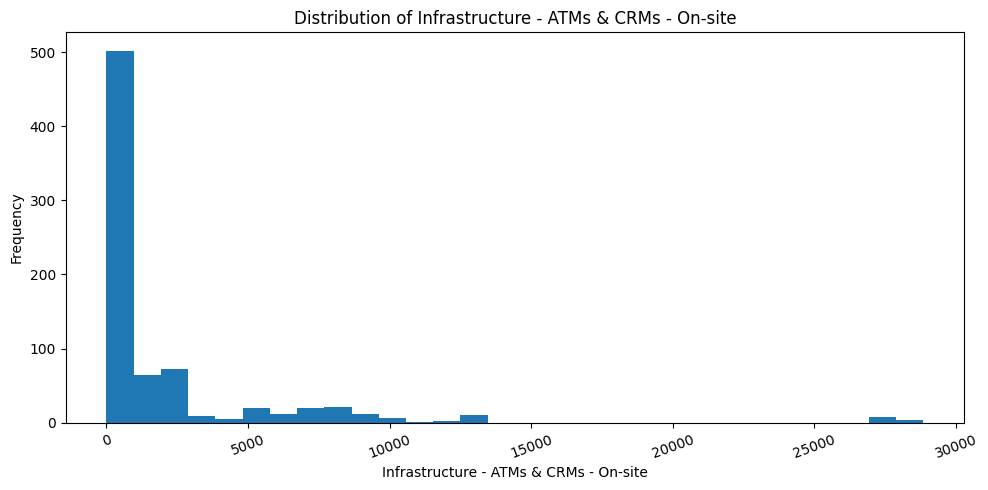

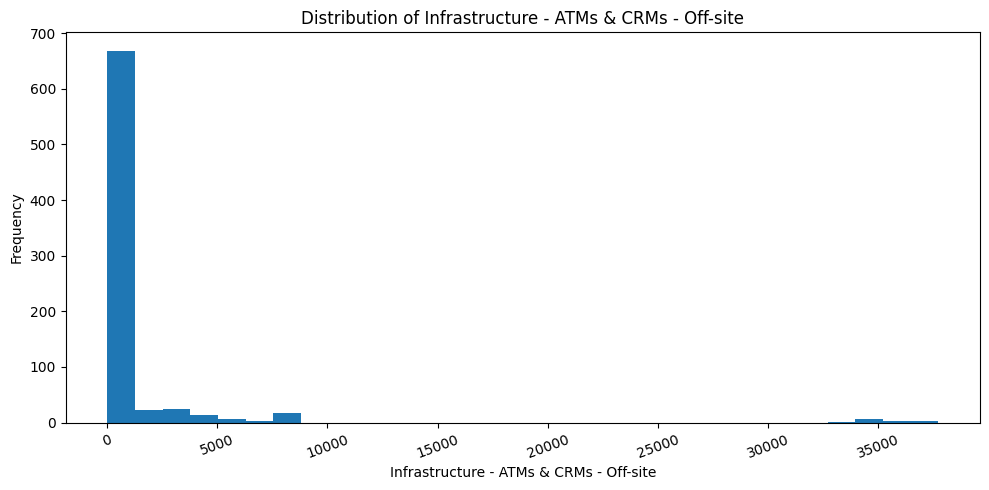

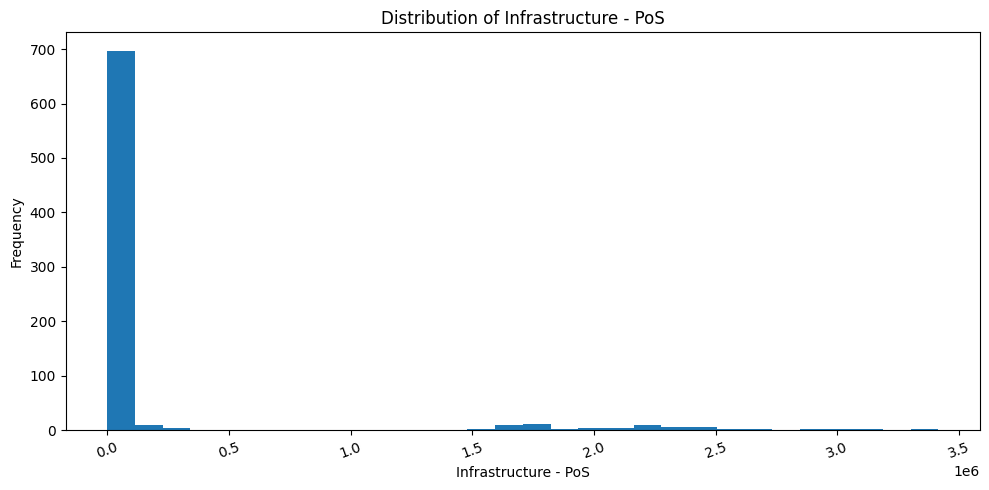

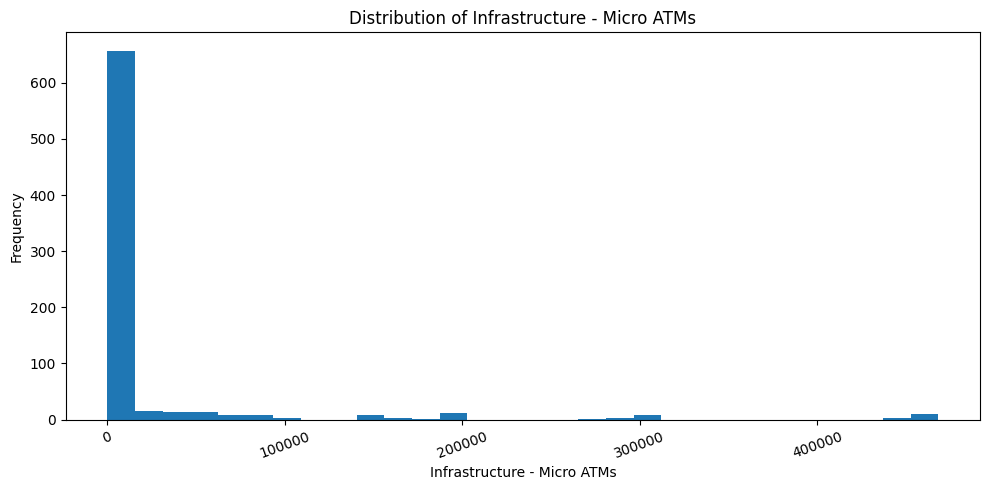

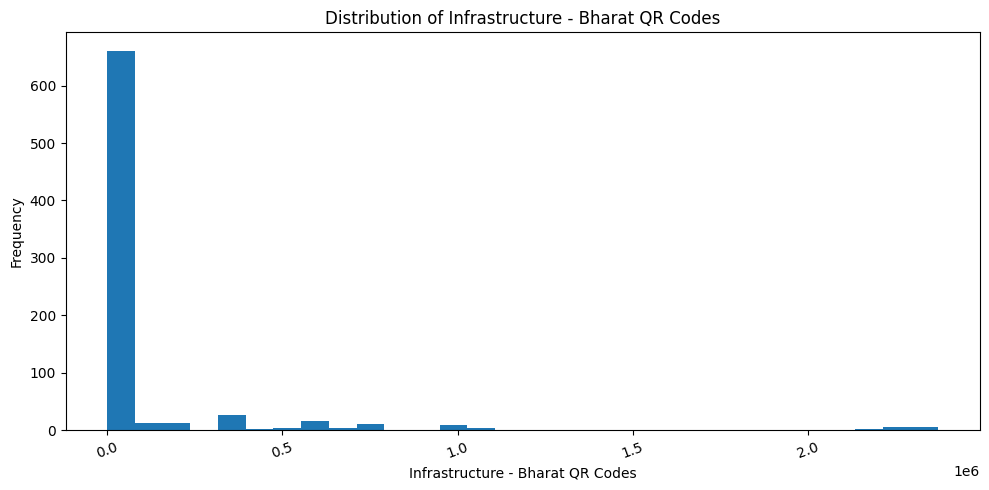

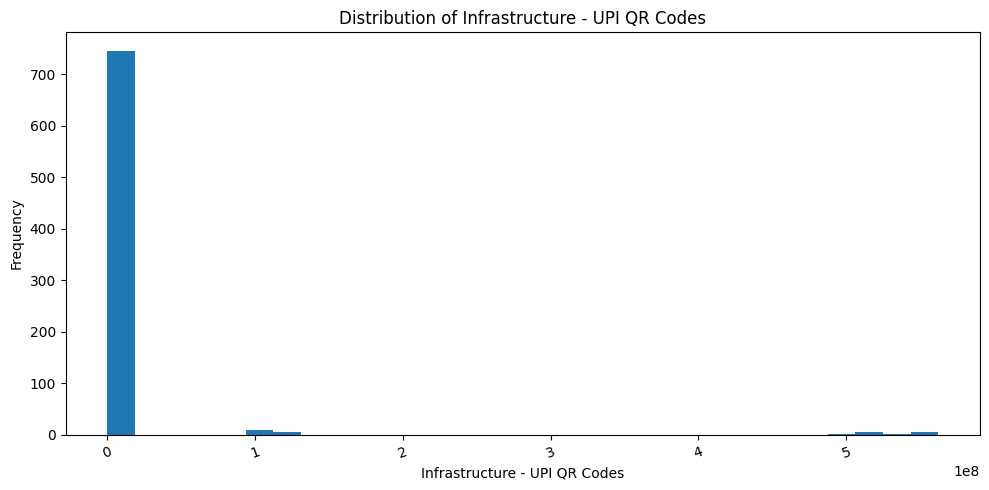

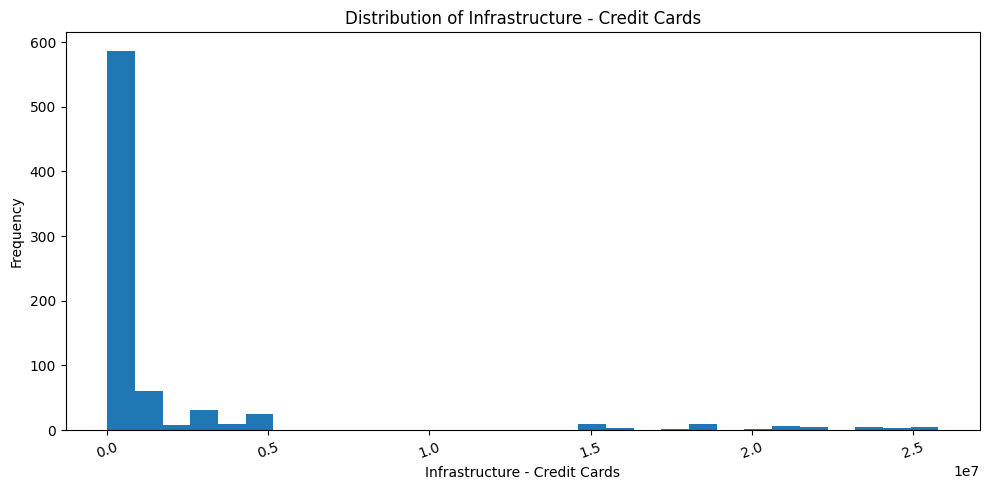

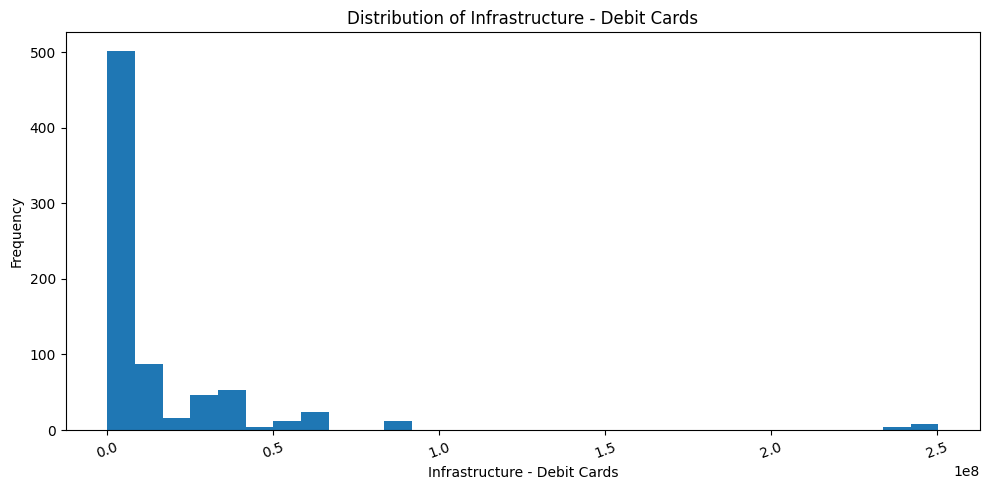

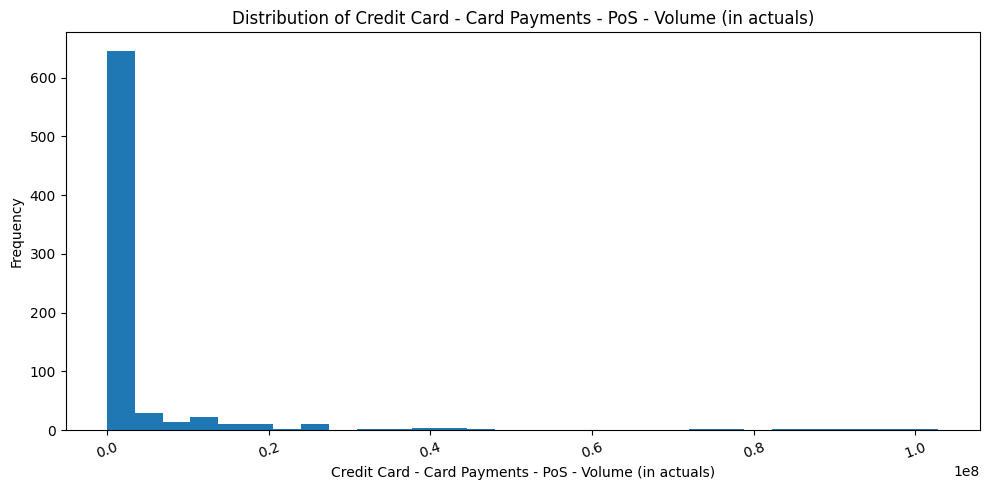

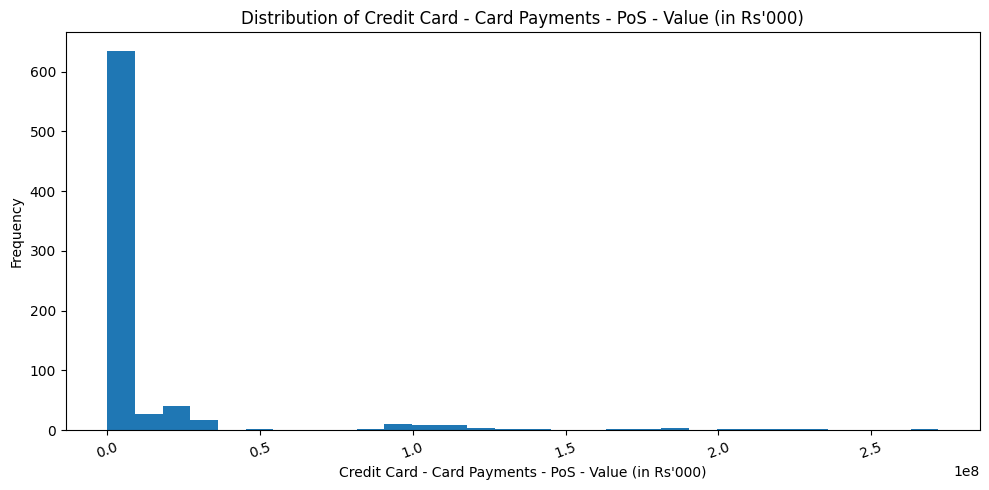

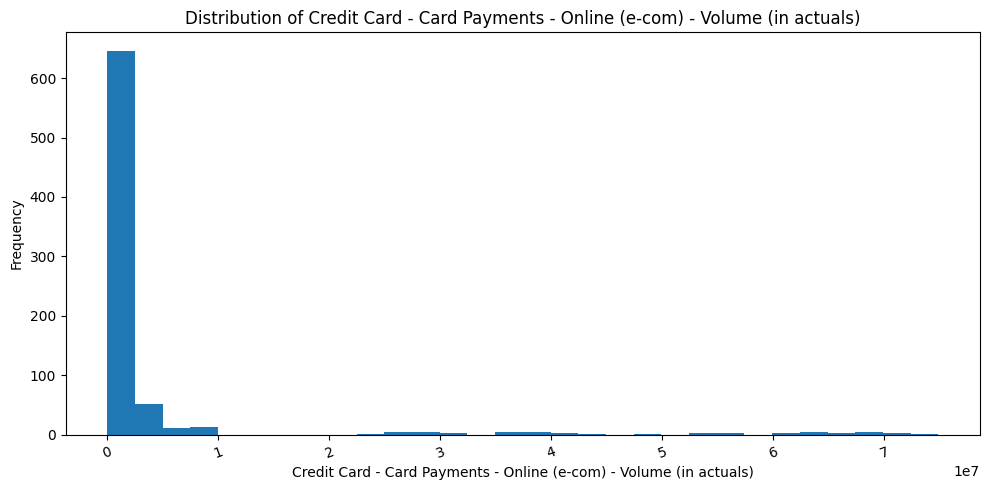

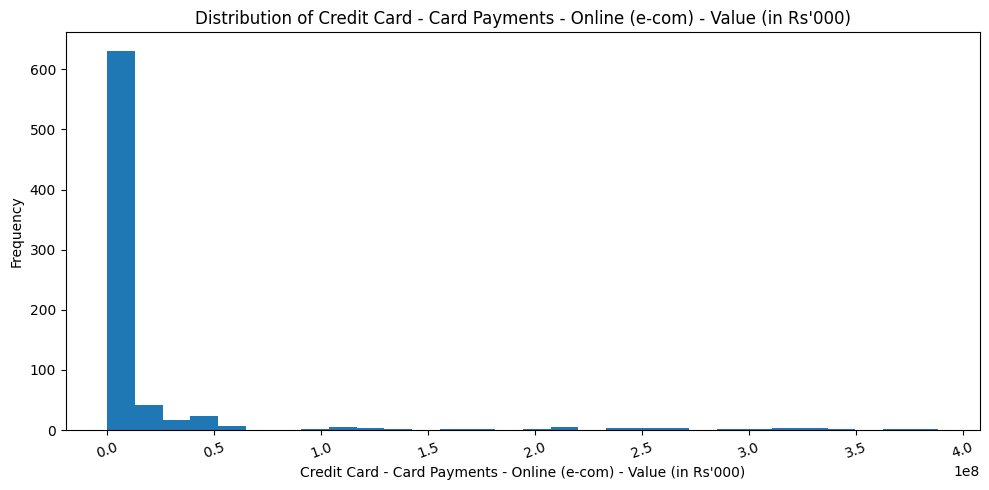

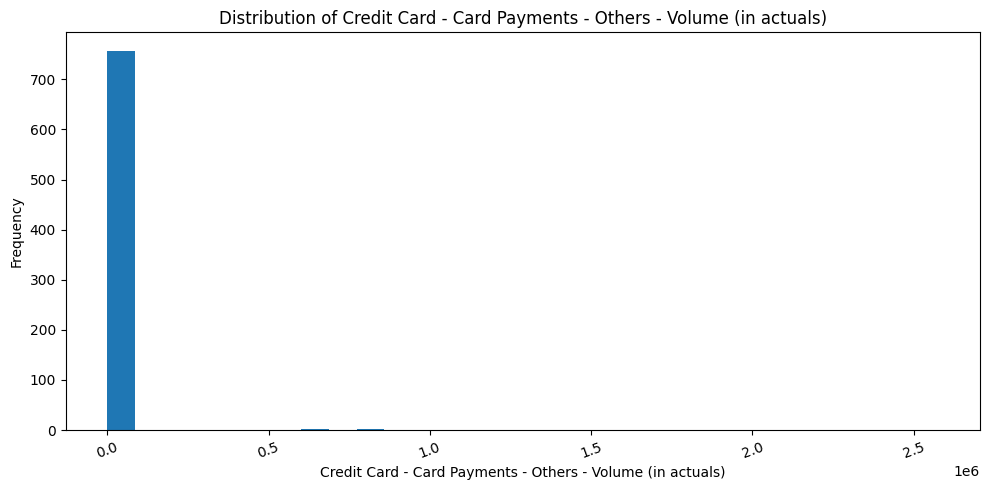

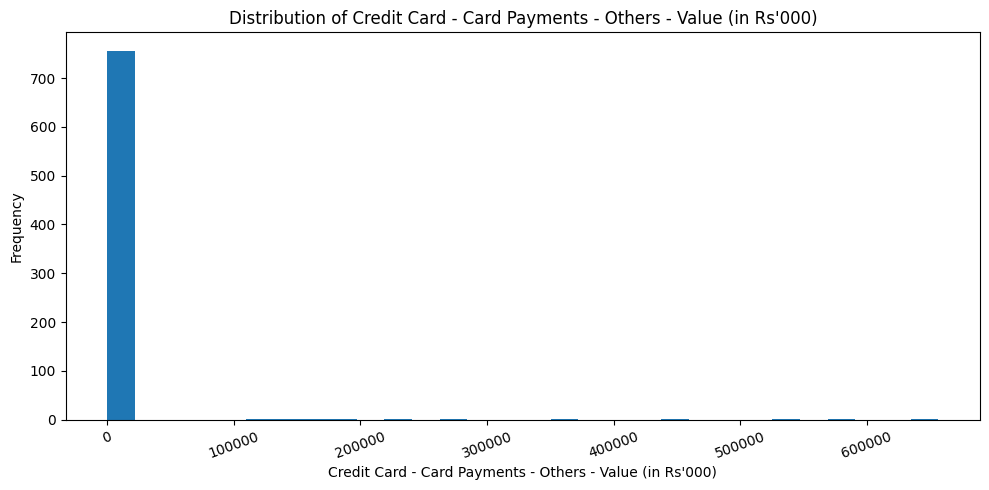

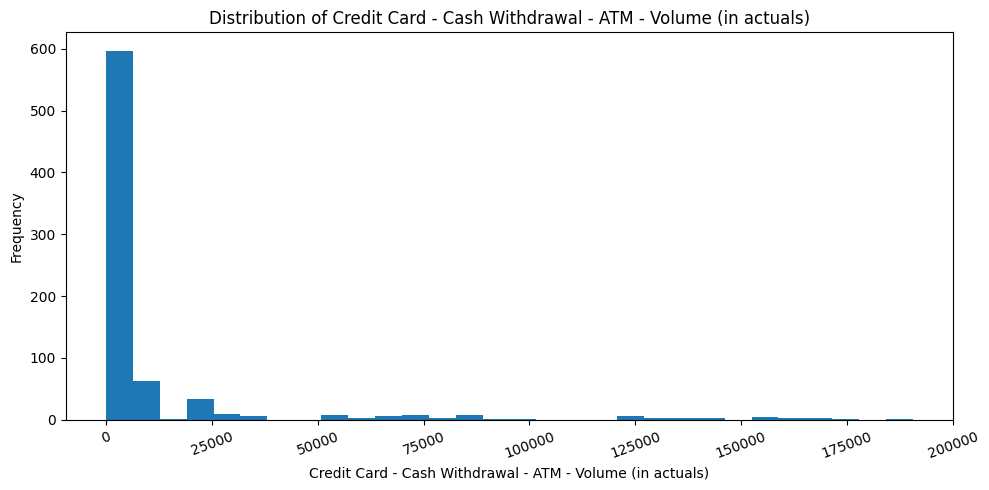

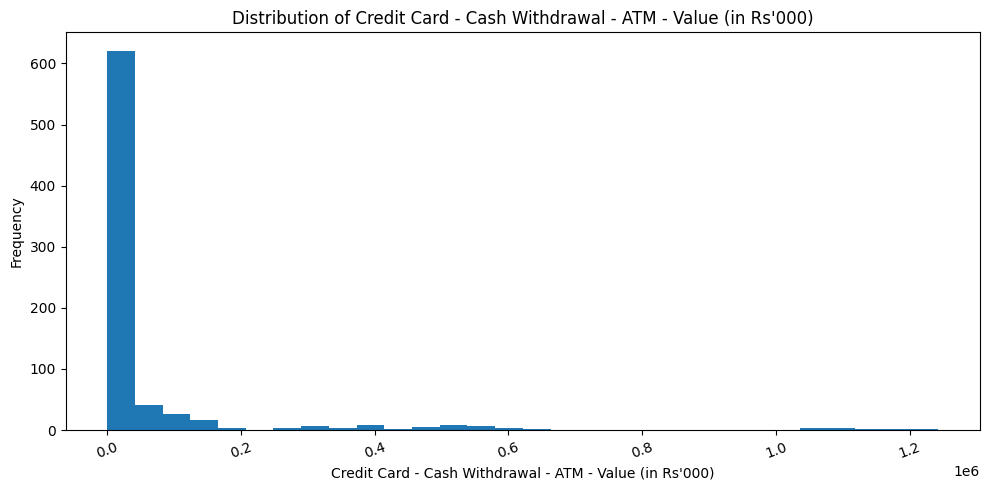

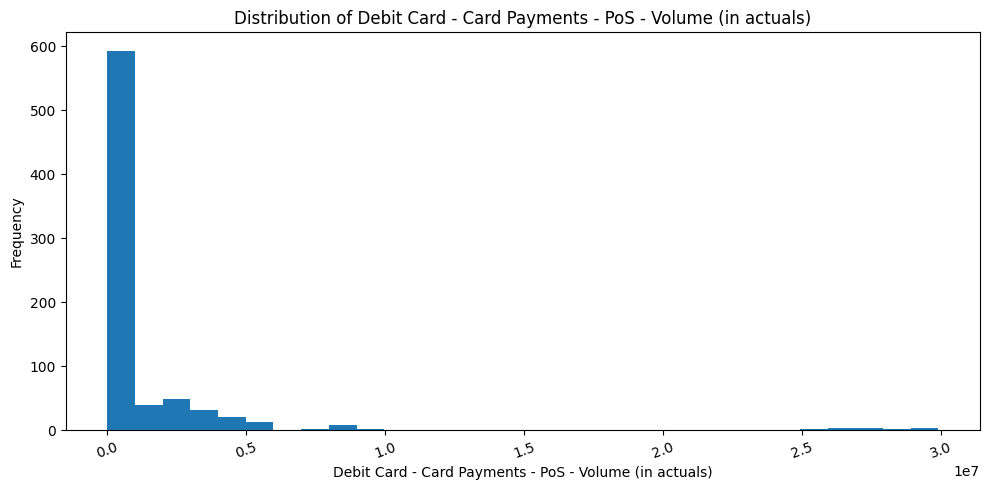

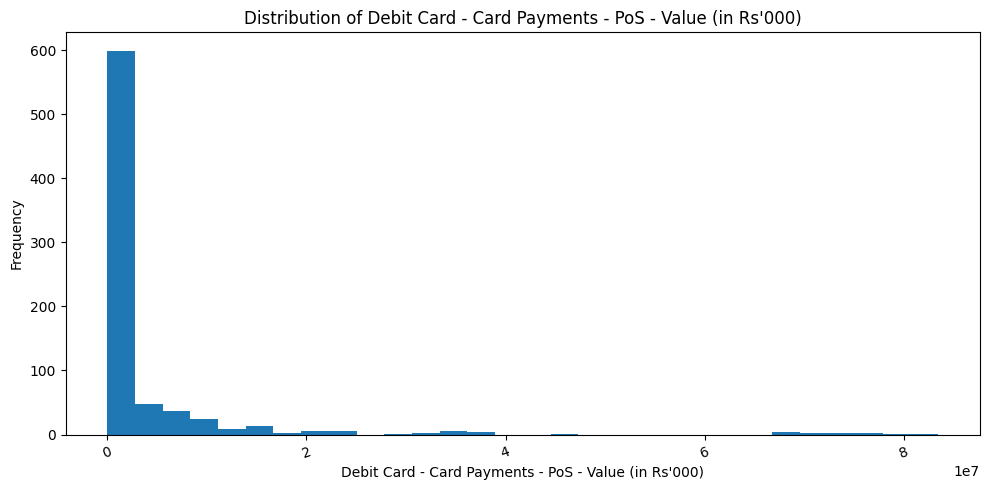

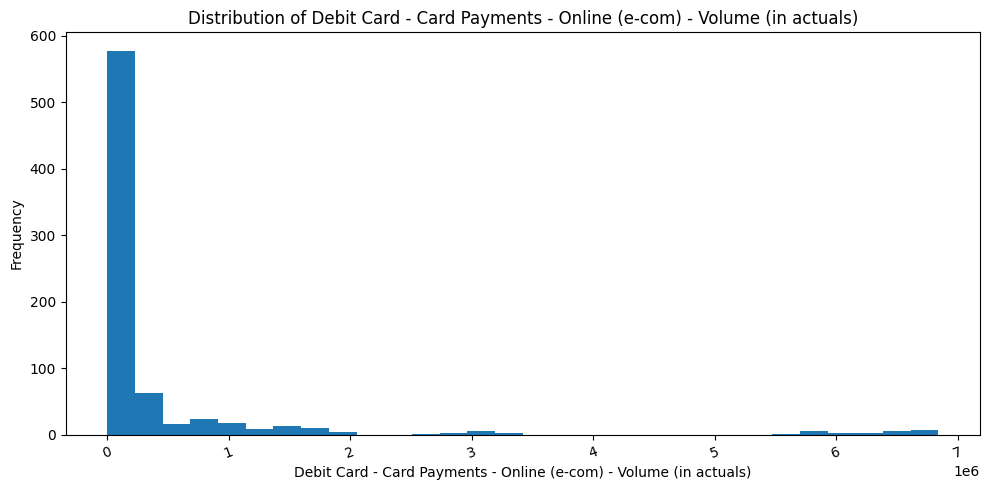

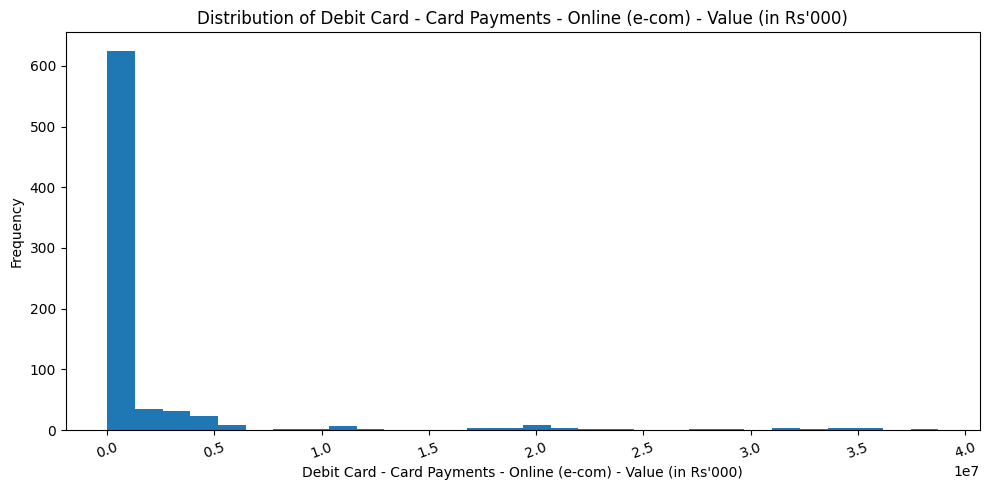

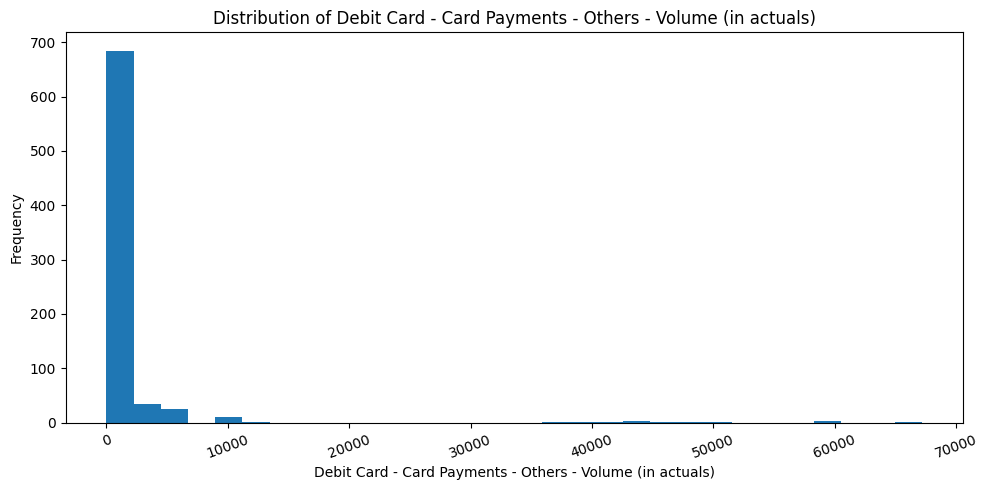

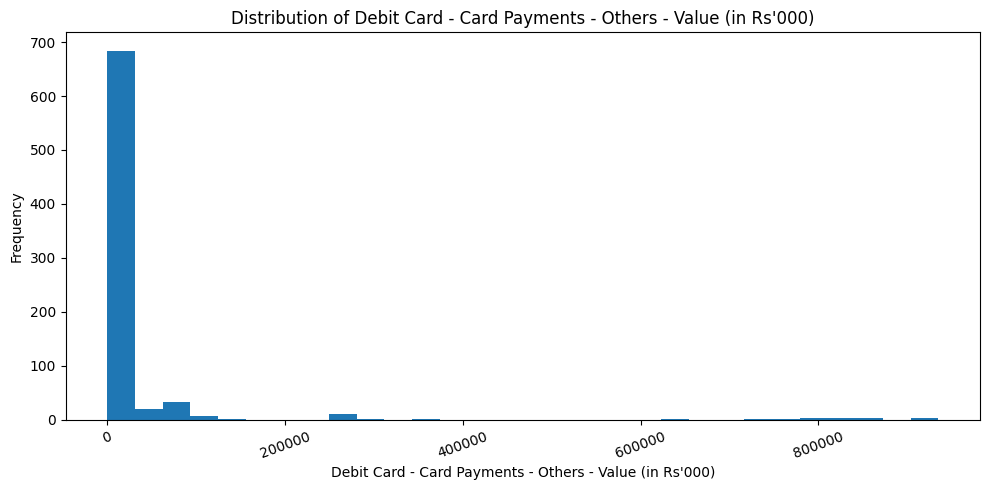

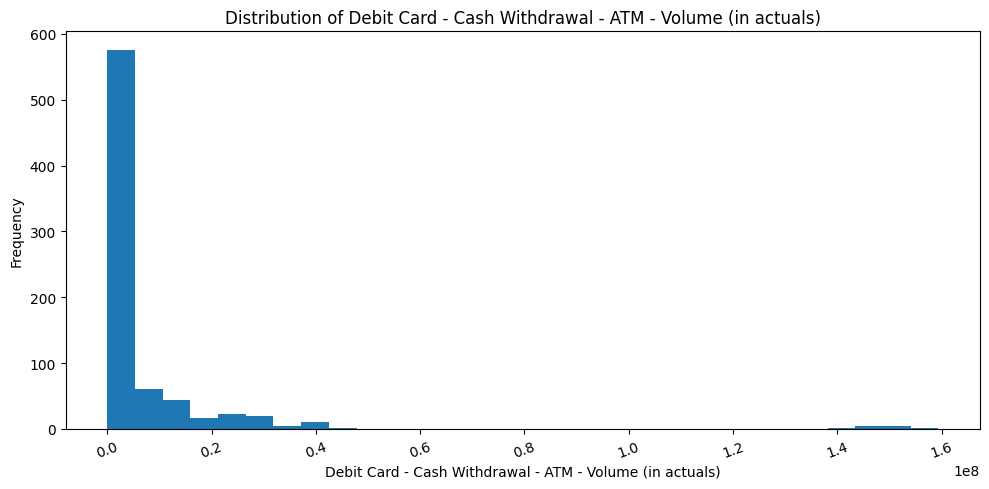

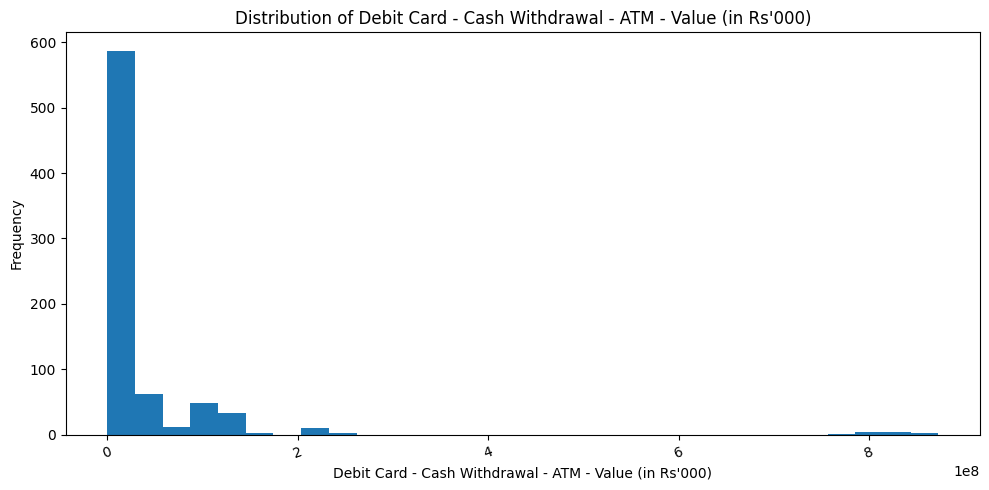

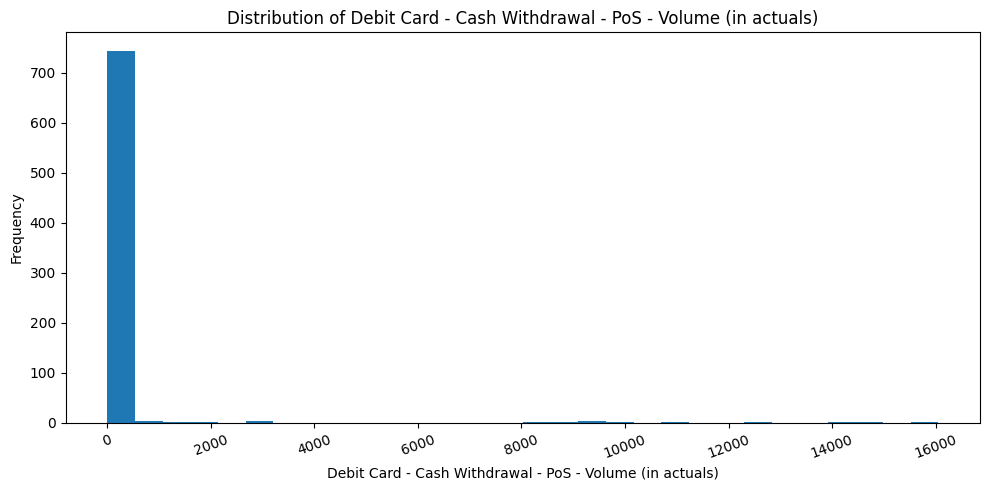

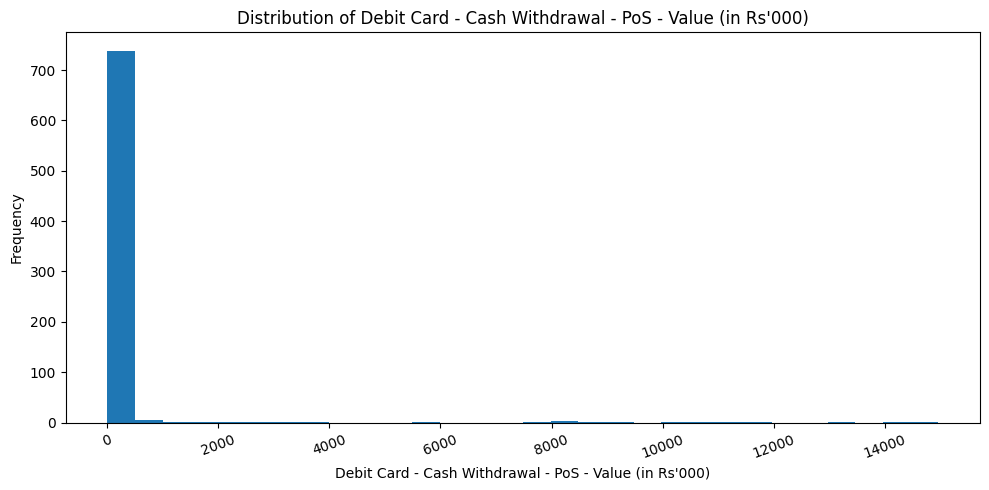


✓ Distribution analysis completed.


In [11]:
# =============================================================================
# DISTRIBUTION ANALYSIS OF NUMERICAL VARIABLES
# =============================================================================

import matplotlib.pyplot as plt

print("=" * 90)
print("DISTRIBUTION ANALYSIS OF NUMERICAL VARIABLES")
print("=" * 90)

# Exclude identifiers and time-index variables from distribution plots
distribution_columns = [
    col for col in numeric_columns
    if col not in ["Year", "Sr. No.", "Month_Num"]
]

print("\nNUMBER OF VARIABLES PLOTTED")
print("-" * 90)
print(f"Variables : {len(distribution_columns)}")

# Create one histogram for each numerical business variable
for col in distribution_columns:
    plt.figure(figsize=(10, 5))
    
    plt.hist(df[col], bins=30)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

print("\n✓ Distribution analysis completed.")

In [12]:
# =============================================================================
# OUTLIER ANALYSIS OF NUMERICAL VARIABLES
# =============================================================================

print("=" * 90)
print("OUTLIER ANALYSIS OF NUMERICAL VARIABLES")
print("=" * 90)

# Business-related numerical variables only
outlier_columns = [
    col for col in numeric_columns
    if col not in ["Year", "Sr. No.", "Month_Num"]
]

outlier_results = []

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)

    outlier_count = outlier_mask.sum()

    outlier_results.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": int(outlier_count),
        "Outlier %": round((outlier_count / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_results)

print("\nOUTLIER SUMMARY")
print("-" * 90)

display(
    outlier_df[
        ["Column", "Outlier Count", "Outlier %"]
    ].sort_values("Outlier Count", ascending=False)
)

print("\nTOP VARIABLES WITH POTENTIAL OUTLIERS")
print("-" * 90)

top_outliers = outlier_df.sort_values(
    "Outlier Count",
    ascending=False
).head(10)

display(top_outliers)

print("\nTOTAL POTENTIAL OUTLIER OBSERVATIONS")
print("-" * 90)

print(
    f"Total outlier cells across numerical business variables : "
    f"{outlier_df['Outlier Count'].sum()}"
)

print("\n✓ Outlier identification completed.")
print("✓ No outliers were removed or modified.")

OUTLIER ANALYSIS OF NUMERICAL VARIABLES

OUTLIER SUMMARY
------------------------------------------------------------------------------------------


,Column,Outlier Count,Outlier %
24,Debit Card - Cash Withdrawal - PoS - Volume (i...,168,21.88
25,Debit Card - Cash Withdrawal - PoS - Value (in...,168,21.88
21,Debit Card - Card Payments - Others - Value (i...,165,21.48
20,Debit Card - Card Payments - Others - Volume (...,164,21.35
4,Infrastructure - Bharat QR Codes,155,20.18
11,Credit Card - Card Payments - Online (e-com) -...,152,19.79
19,Debit Card - Card Payments - Online (e-com) - ...,144,18.75
9,Credit Card - Card Payments - PoS - Value (in ...,143,18.62
2,Infrastructure - PoS,137,17.84
8,Credit Card - Card Payments - PoS - Volume (in...,132,17.19



TOP VARIABLES WITH POTENTIAL OUTLIERS
------------------------------------------------------------------------------------------


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
24,Debit Card - Cash Withdrawal - PoS - Volume (i...,0.00,0.00,0.00,0.00,0.00,168,21.88
25,Debit Card - Cash Withdrawal - PoS - Value (in...,0.00,0.00,0.00,0.00,0.00,168,21.88
21,Debit Card - Card Payments - Others - Value (i...,0.00,341.21,341.21,-511.81,853.02,165,21.48
20,Debit Card - Card Payments - Others - Volume (...,0.00,46.50,46.50,-69.75,116.25,164,21.35
4,Infrastructure - Bharat QR Codes,0.00,"12,205.75","12,205.75","-18,308.62","30,514.38",155,20.18
11,Credit Card - Card Payments - Online (e-com) -...,0.00,"3,955,947.45","3,955,947.45","-5,933,921.18","9,889,868.63",152,19.79
19,Debit Card - Card Payments - Online (e-com) - ...,"11,451.26","759,964.34","748,513.08","-1,111,318.35","1,882,733.95",144,18.75
9,Credit Card - Card Payments - PoS - Value (in ...,0.00,"2,593,320.61","2,593,320.61","-3,889,980.91","6,483,301.52",143,18.62
2,Infrastructure - PoS,0.00,"19,858.25","19,858.25","-29,787.38","49,645.62",137,17.84
8,Credit Card - Card Payments - PoS - Volume (in...,0.00,"734,425.25","734,425.25","-1,101,637.88","1,836,063.12",132,17.19



TOTAL POTENTIAL OUTLIER OBSERVATIONS
------------------------------------------------------------------------------------------
Total outlier cells across numerical business variables : 3217

✓ Outlier identification completed.
✓ No outliers were removed or modified.


CORRELATION HEATMAP


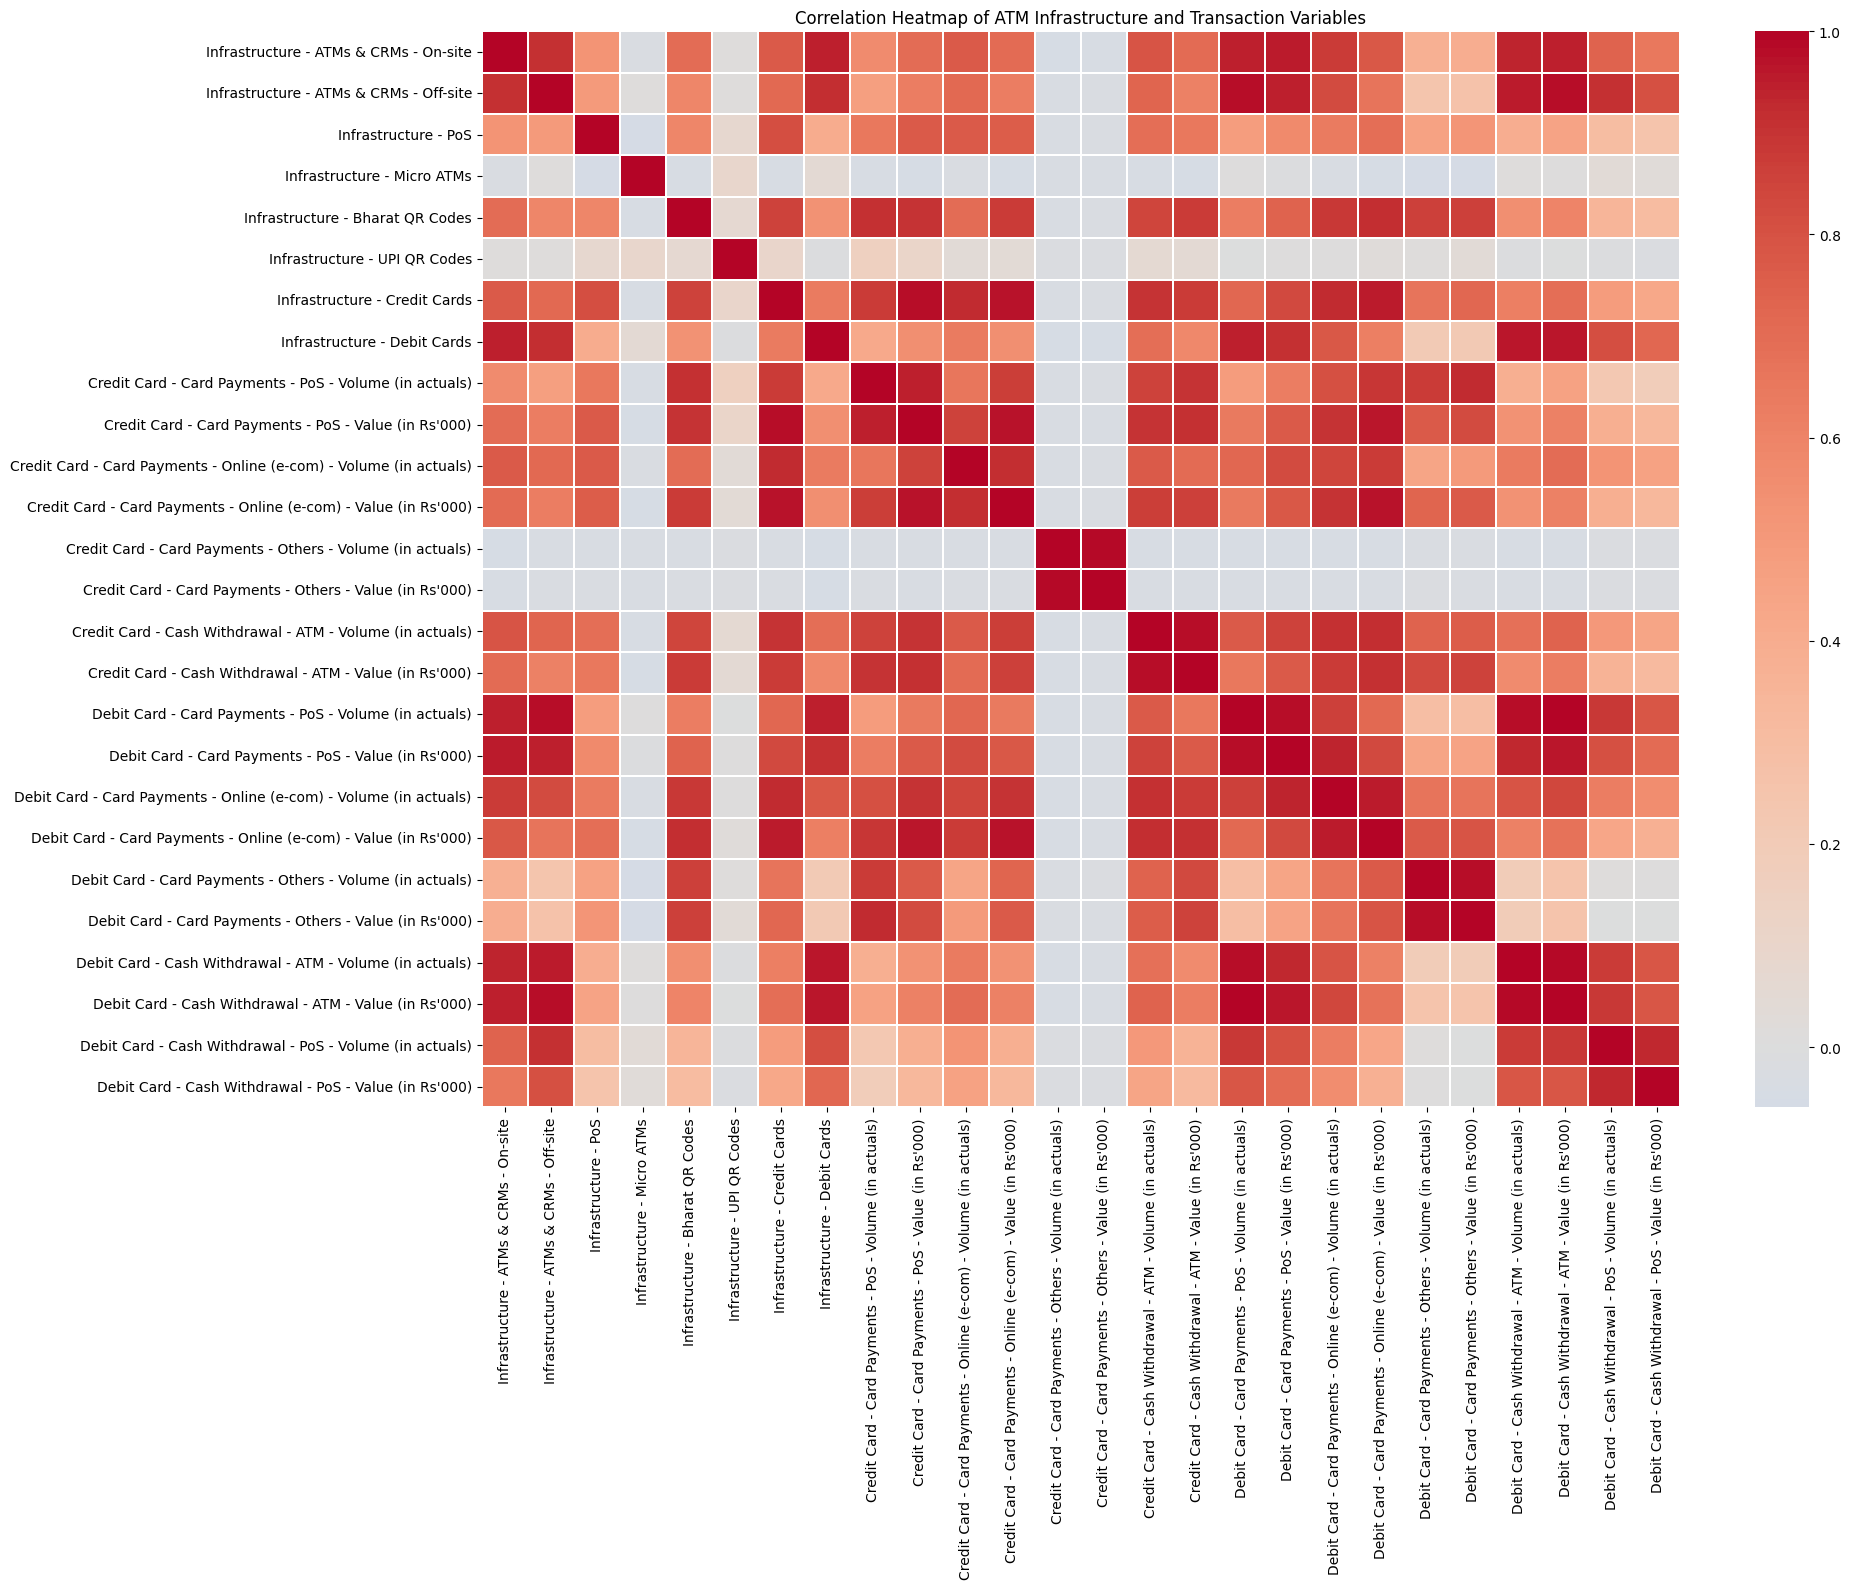


✓ Correlation heatmap generated successfully.


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 90)
print("CORRELATION HEATMAP")
print("=" * 90)

plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Heatmap of ATM Infrastructure and Transaction Variables")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✓ Correlation heatmap generated successfully.")

TIME-BASED ANALYSIS

MONTHLY TRANSACTION VOLUME
------------------------------------------------------------------------------------------


,Credit Card - Card Payments - PoS - Volume (in actuals),Credit Card - Card Payments - Online (e-com) - Volume (in actuals),Credit Card - Cash Withdrawal - ATM - Volume (in actuals),Debit Card - Card Payments - PoS - Volume (in actuals),Debit Card - Card Payments - Online (e-com) - Volume (in actuals),Debit Card - Cash Withdrawal - ATM - Volume (in actuals)
Date,,,,,,
2025-01-01,217743317,212193992,779153,91091391,30470254,488353232
2025-02-01,199995593,196284815,684455,80342355,27813305,447376890
2025-03-01,230266329,227565189,743191,89581561,30622450,495721528
2025-04-01,228140764,221275020,686493,87530236,29478270,457805976
2025-05-01,235914154,230745664,670129,86156629,28805524,457987566
2025-06-01,233869565,223606182,628066,81289624,27210465,435858139
2025-07-01,243275291,241322355,662973,83219175,28764405,444765520
2025-08-01,250162542,241618661,671163,84359478,27641922,460136709
2025-09-01,241614615,251718295,668889,77755830,26904171,437090119



✓ Monthly transaction totals calculated.


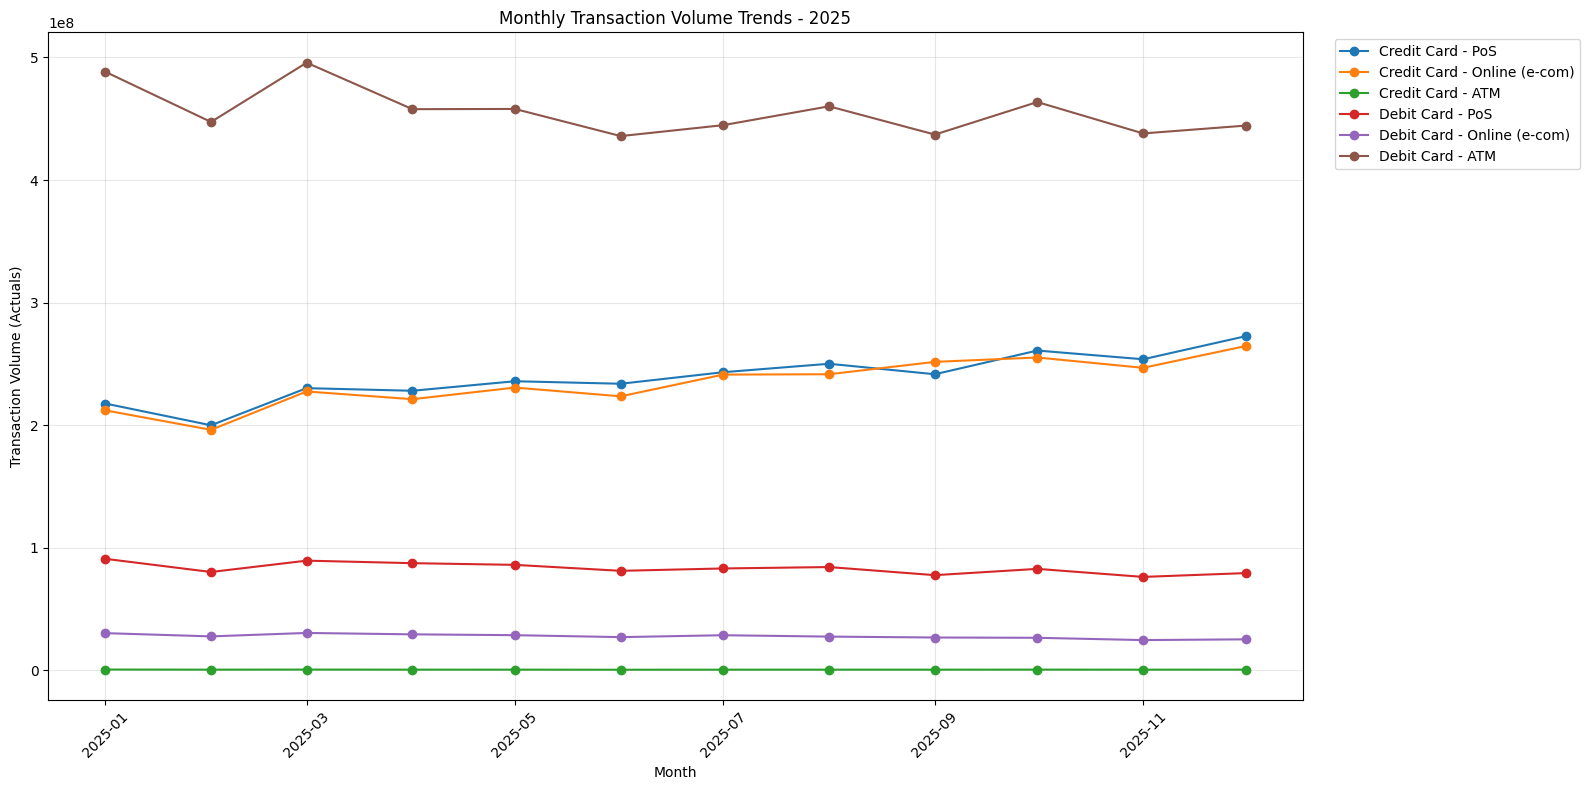


✓ Monthly transaction trend analysis completed.


In [15]:
# =============================================================================
# TIME-BASED ANALYSIS
# =============================================================================

print("=" * 90)
print("TIME-BASED ANALYSIS")
print("=" * 90)

# Ensure Date is in datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Sort chronologically
df = df.sort_values("Date").reset_index(drop=True)

# Select major transaction variables
time_cols = [
    "Credit Card - Card Payments - PoS - Volume (in actuals)",
    "Credit Card - Card Payments - Online (e-com) - Volume (in actuals)",
    "Credit Card - Cash Withdrawal - ATM - Volume (in actuals)",
    "Debit Card - Card Payments - PoS - Volume (in actuals)",
    "Debit Card - Card Payments - Online (e-com) - Volume (in actuals)",
    "Debit Card - Cash Withdrawal - ATM - Volume (in actuals)"
]

# Monthly totals
monthly_totals = df.groupby("Date")[time_cols].sum()

print("\nMONTHLY TRANSACTION VOLUME")
print("-" * 90)
display(monthly_totals.round(2))

print("\n✓ Monthly transaction totals calculated.")

# Plot monthly trends
plt.figure(figsize=(16, 8))

for col in time_cols:
    plt.plot(
        monthly_totals.index,
        monthly_totals[col],
        marker="o",
        label=col.split(" - ")[0] + " - " + col.split(" - ")[2]
    )

plt.title("Monthly Transaction Volume Trends - 2025")
plt.xlabel("Month")
plt.ylabel("Transaction Volume (Actuals)")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Monthly transaction trend analysis completed.")

In [16]:
print("=" * 90)
print("MONTHLY TRANSACTION VALUE ANALYSIS")
print("=" * 90)

value_cols = [
    "Credit Card - Card Payments - PoS - Value (in Rs'000)",
    "Credit Card - Card Payments - Online (e-com) - Value (in Rs'000)",
    "Credit Card - Cash Withdrawal - ATM - Value (in Rs'000)",
    "Debit Card - Card Payments - PoS - Value (in Rs'000)",
    "Debit Card - Card Payments - Online (e-com) - Value (in Rs'000)",
    "Debit Card - Cash Withdrawal - ATM - Value (in Rs'000)"
]

monthly_value = df.groupby("Date")[value_cols].sum()

print("\nMONTHLY TRANSACTION VALUE")
print("-" * 90)
display(monthly_value)

print("\n✓ Monthly transaction value totals calculated.")

MONTHLY TRANSACTION VALUE ANALYSIS

MONTHLY TRANSACTION VALUE
------------------------------------------------------------------------------------------


,Credit Card - Card Payments - PoS - Value (in Rs'000),Credit Card - Card Payments - Online (e-com) - Value (in Rs'000),Credit Card - Cash Withdrawal - ATM - Value (in Rs'000),Debit Card - Card Payments - PoS - Value (in Rs'000),Debit Card - Card Payments - Online (e-com) - Value (in Rs'000),Debit Card - Cash Withdrawal - ATM - Value (in Rs'000)
Date,,,,,,
2025-01-01,"694,294,042.21","1,146,850,748.01","4,123,901.73","259,987,962.17","127,934,625.18","2,506,460,607.30"
2025-02-01,"621,249,130.88","1,050,707,807.52","3,697,634.57","232,162,171.98","109,529,321.82","2,344,079,628.15"
2025-03-01,"714,730,077.17","1,300,057,487.55","4,101,395.94","258,180,395.94","130,773,576.59","2,625,397,946.67"
2025-04-01,"678,992,925.28","1,163,224,296.02","3,727,257.29","261,874,888.81","117,862,833.25","2,434,935,535.81"
2025-05-01,"696,074,160.48","1,202,052,736.01","3,701,259.94","247,354,380.78","120,964,648.06","2,449,449,083.29"
2025-06-01,"674,677,887.21","1,155,976,975.23","3,448,545.70","230,792,378.89","122,547,768.89","2,287,346,695.82"
2025-07-01,"703,803,113.23","1,234,403,844.97","3,616,171.86","239,211,901.07","140,662,220.75","2,317,224,285.39"
2025-08-01,"727,533,230.45","1,183,810,974.63","3,656,376.27","246,628,177.13","125,993,029.86","2,388,831,511.35"
2025-09-01,"725,438,997.96","1,441,177,813.64","3,688,141.52","227,726,759.10","138,542,744.83","2,297,133,845.25"



✓ Monthly transaction value totals calculated.


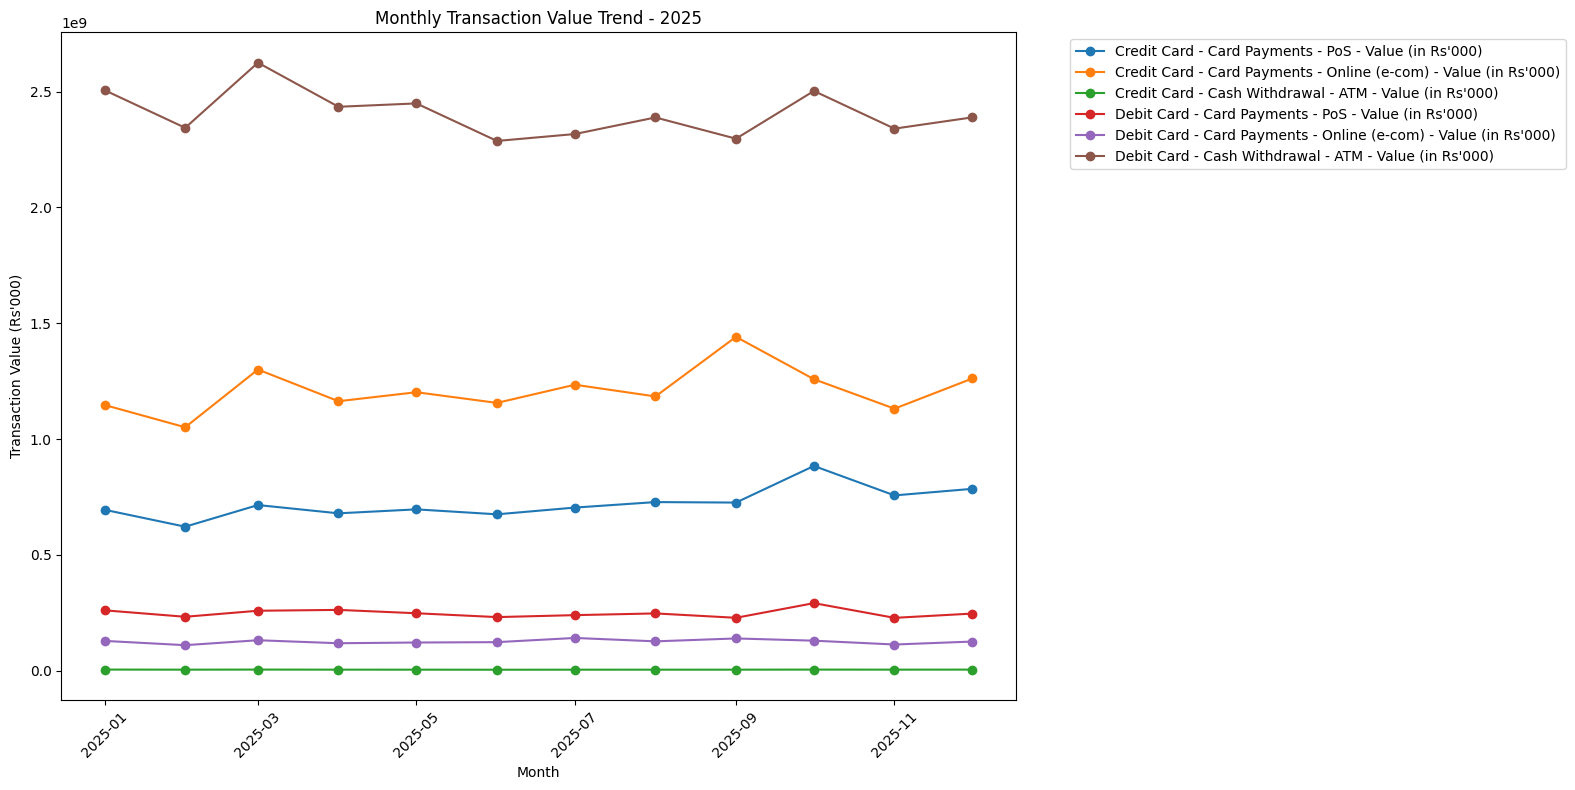


✓ Monthly transaction value trend analysis completed.


In [17]:
plt.figure(figsize=(16, 8))

for col in value_cols:
    plt.plot(
        monthly_value.index,
        monthly_value[col],
        marker="o",
        label=col
    )

plt.title("Monthly Transaction Value Trend - 2025")
plt.xlabel("Month")
plt.ylabel("Transaction Value (Rs'000)")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("\n✓ Monthly transaction value trend analysis completed.")

In [18]:
print("=" * 90)
print("BANK CATEGORY ANALYSIS")
print("=" * 90)

category_summary = df.groupby("Bank Category").agg(
    Banks=("Bank Name", "nunique"),
    ATM_Onsite=("Infrastructure - ATMs & CRMs - On-site", "sum"),
    ATM_Offsite=("Infrastructure - ATMs & CRMs - Off-site", "sum"),
    PoS=("Infrastructure - PoS", "sum"),
    Credit_Cards=("Infrastructure - Credit Cards", "sum"),
    Debit_Cards=("Infrastructure - Debit Cards", "sum"),
    Credit_Card_PoS_Volume=(
        "Credit Card - Card Payments - PoS - Volume (in actuals)", "sum"
    ),
    Credit_Card_Online_Volume=(
        "Credit Card - Card Payments - Online (e-com) - Volume (in actuals)", "sum"
    ),
    Debit_Card_PoS_Volume=(
        "Debit Card - Card Payments - PoS - Volume (in actuals)", "sum"
    ),
    Debit_Card_Online_Volume=(
        "Debit Card - Card Payments - Online (e-com) - Volume (in actuals)", "sum"
    ),
    Debit_Card_ATM_Withdrawal_Volume=(
        "Debit Card - Cash Withdrawal - ATM - Volume (in actuals)", "sum"
    )
).sort_values("Debit_Card_ATM_Withdrawal_Volume", ascending=False)

print("\nBANK CATEGORY SUMMARY")
print("-" * 90)

display(category_summary)

print("\n✓ Bank category summary calculated.")

BANK CATEGORY ANALYSIS

BANK CATEGORY SUMMARY
------------------------------------------------------------------------------------------


,Banks,ATM_Onsite,ATM_Offsite,PoS,Credit_Cards,Debit_Cards,Credit_Card_PoS_Volume,Credit_Card_Online_Volume,Debit_Card_PoS_Volume,Debit_Card_Online_Volume,Debit_Card_ATM_Withdrawal_Volume
Bank Category,,,,,,,,,,,
Public Sector Banks,12,970355,625664,22828886,322185706,7688992388,431099153,770743597,639320312,135736593,3949584819
Private Sector Banks,21,569676,316700,114787927,952123304,3059834646,2372627479,1915970389,336987246,190252180,1371332091
Small Finance Banks,12,37827,340,32558,14439842,377126552,12806625,28947996,7475156,3015919,95987100
Payment Banks,6,0,0,0,0,930472369,0,0,7722388,2951036,37296919
Foreign Banks,14,6975,5029,196438,54518178,52414157,51862088,97412230,8466796,2632881,16952732



✓ Bank category summary calculated.


In [19]:
print("=" * 90)
print("BANK CATEGORY - TRANSACTION VOLUME")
print("=" * 90)

category_volume = df.groupby("Bank Category")[
    [
        "Credit Card - Card Payments - PoS - Volume (in actuals)",
        "Credit Card - Card Payments - Online (e-com) - Volume (in actuals)",
        "Credit Card - Cash Withdrawal - ATM - Volume (in actuals)",
        "Debit Card - Card Payments - PoS - Volume (in actuals)",
        "Debit Card - Card Payments - Online (e-com) - Volume (in actuals)",
        "Debit Card - Cash Withdrawal - ATM - Volume (in actuals)"
    ]
].sum()

display(category_volume)

print("\n✓ Category-wise transaction volumes calculated.")

BANK CATEGORY - TRANSACTION VOLUME


,Credit Card - Card Payments - PoS - Volume (in actuals),Credit Card - Card Payments - Online (e-com) - Volume (in actuals),Credit Card - Cash Withdrawal - ATM - Volume (in actuals),Debit Card - Card Payments - PoS - Volume (in actuals),Debit Card - Card Payments - Online (e-com) - Volume (in actuals),Debit Card - Cash Withdrawal - ATM - Volume (in actuals)
Bank Category,,,,,,
Foreign Banks,51862088,97412230,113066,8466796,2632881,16952732
Payment Banks,0,0,0,7722388,2951036,37296919
Private Sector Banks,2372627479,1915970389,5035372,336987246,190252180,1371332091
Public Sector Banks,431099153,770743597,3084605,639320312,135736593,3949584819
Small Finance Banks,12806625,28947996,41266,7475156,3015919,95987100



✓ Category-wise transaction volumes calculated.


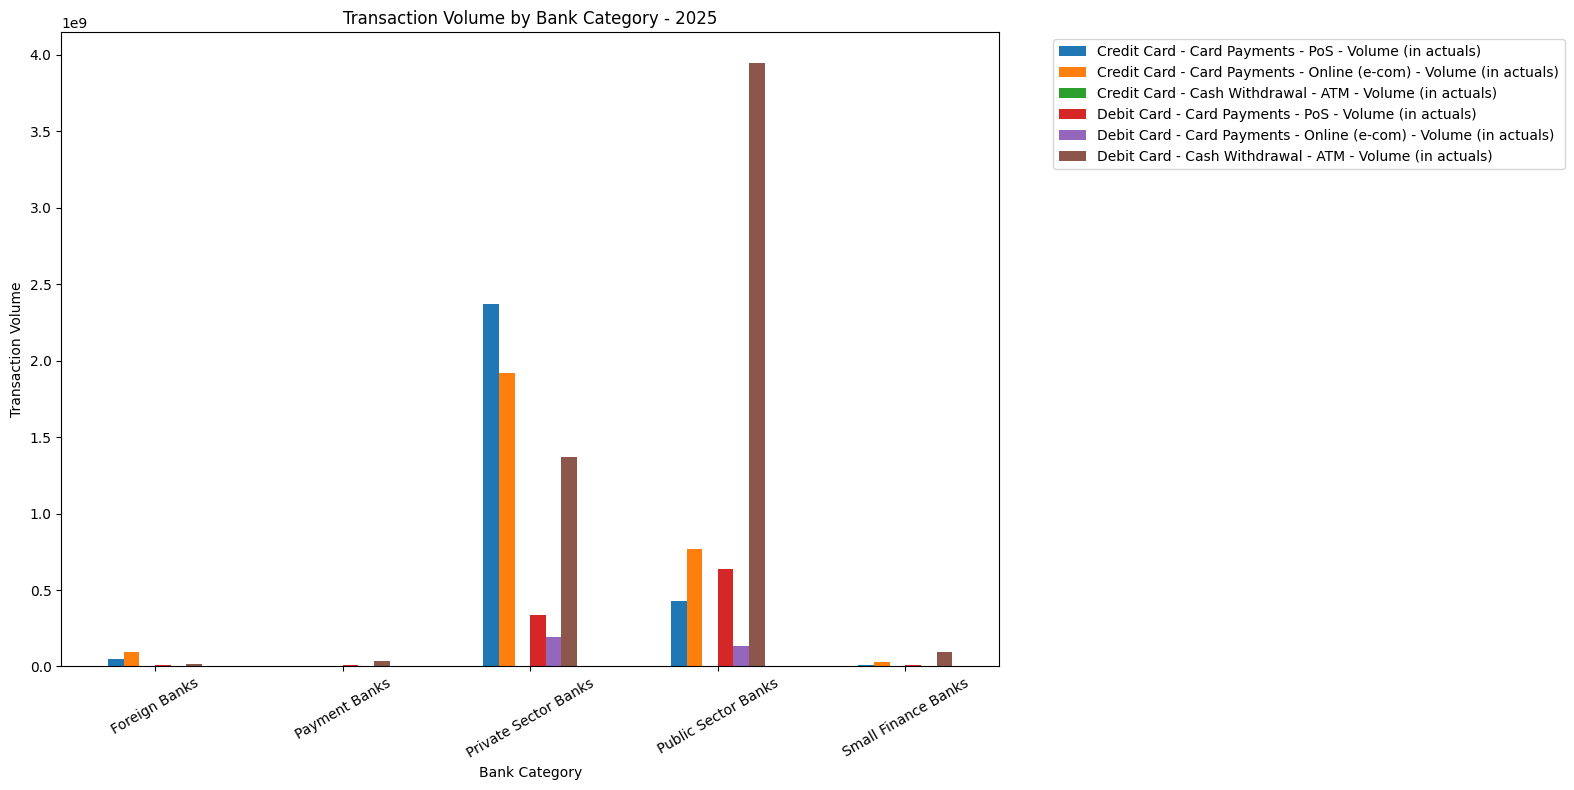


✓ Bank category transaction volume analysis completed.


In [20]:
import matplotlib.pyplot as plt

category_volume.plot(
    kind="bar",
    figsize=(16, 8)
)

plt.title("Transaction Volume by Bank Category - 2025")
plt.xlabel("Bank Category")
plt.ylabel("Transaction Volume")
plt.xticks(rotation=30)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

print("\n✓ Bank category transaction volume analysis completed.")

In [21]:
print("=" * 90)
print("BANK CATEGORY - TRANSACTION VALUE")
print("=" * 90)

value_cols = [
    "Credit Card - Card Payments - PoS - Value (in Rs'000)",
    "Credit Card - Card Payments - Online (e-com) - Value (in Rs'000)",
    "Credit Card - Cash Withdrawal - ATM - Value (in Rs'000)",
    "Debit Card - Card Payments - PoS - Value (in Rs'000)",
    "Debit Card - Card Payments - Online (e-com) - Value (in Rs'000)",
    "Debit Card - Cash Withdrawal - ATM - Value (in Rs'000)"
]

category_value = df.groupby("Bank Category")[value_cols].sum()

display(category_value)

print("\n✓ Category-wise transaction values calculated.")

BANK CATEGORY - TRANSACTION VALUE


,Credit Card - Card Payments - PoS - Value (in Rs'000),Credit Card - Card Payments - Online (e-com) - Value (in Rs'000),Credit Card - Cash Withdrawal - ATM - Value (in Rs'000),Debit Card - Card Payments - PoS - Value (in Rs'000),Debit Card - Card Payments - Online (e-com) - Value (in Rs'000),Debit Card - Cash Withdrawal - ATM - Value (in Rs'000)
Bank Category,,,,,,
Foreign Banks,"309,503,147.74","792,682,682.68","626,254.51","35,501,727.09","10,277,908.81","98,442,067.76"
Payment Banks,0.00,0.00,0.00,"4,319,343.20","4,009,760.88","129,332,785.21"
Private Sector Banks,"6,576,720,854.07","10,757,965,110.55","29,406,478.04","1,252,970,509.61","1,016,652,084.10","8,686,274,291.44"
Public Sector Banks,"1,719,702,039.99","2,908,527,899.58","15,277,622.77","1,656,824,932.05","456,627,103.94","19,570,666,527.68"
Small Finance Banks,"55,600,987.85","69,705,338.40","205,223.46","18,869,991.38","13,617,469.49","399,151,583.19"



✓ Category-wise transaction values calculated.


In [22]:
print("=" * 90)
print("BANK-WISE PERFORMANCE ANALYSIS")
print("=" * 90)

bank_summary = df.groupby("Bank Name").agg(
    Bank_Category=("Bank Category", "first"),
    
    ATM_Onsite=(
        "Infrastructure - ATMs & CRMs - On-site", "sum"
    ),
    ATM_Offsite=(
        "Infrastructure - ATMs & CRMs - Off-site", "sum"
    ),
    PoS=(
        "Infrastructure - PoS", "sum"
    ),
    Credit_Cards=(
        "Infrastructure - Credit Cards", "sum"
    ),
    Debit_Cards=(
        "Infrastructure - Debit Cards", "sum"
    ),
    
    Credit_PoS_Volume=(
        "Credit Card - Card Payments - PoS - Volume (in actuals)", "sum"
    ),
    Credit_Online_Volume=(
        "Credit Card - Card Payments - Online (e-com) - Volume (in actuals)", "sum"
    ),
    Debit_PoS_Volume=(
        "Debit Card - Card Payments - PoS - Volume (in actuals)", "sum"
    ),
    Debit_Online_Volume=(
        "Debit Card - Card Payments - Online (e-com) - Volume (in actuals)", "sum"
    ),
    Debit_ATM_Volume=(
        "Debit Card - Cash Withdrawal - ATM - Volume (in actuals)", "sum"
    )
)

display(bank_summary)

print("\n✓ Bank-wise summary calculated.")

BANK-WISE PERFORMANCE ANALYSIS


,Bank_Category,ATM_Onsite,ATM_Offsite,PoS,Credit_Cards,Debit_Cards,Credit_PoS_Volume,Credit_Online_Volume,Debit_PoS_Volume,Debit_Online_Volume,Debit_ATM_Volume
Bank Name,,,,,,,,,,,
AIRTEL PAYMENTS BANK,Payment Banks,0,0,0,0,86628847,0,0,5895920,402322,5652172
AMERICAN EXPRESS BANKING CORPORATION,Foreign Banks,0,0,188511,16757420,0,19793296,50097911,0,0,0
AU SMALL FINANCE BANK LTD,Small Finance Banks,8278,72,0,11782488,106914361,10212377,27377992,1990511,1944108,16128125
AXIS BANK LTD,Private Sector Banks,78043,85398,27711822,182165151,487121779,490909197,333377400,46192847,20949521,188836343
BANDHAN BANK LTD,Private Sector Banks,5116,60,836561,5998,76574340,2253,1602,2383268,611944,24927074
BANK OF AMERICA,Foreign Banks,0,0,0,0,0,0,0,0,0,0
BANK OF BAHRAIN & KUWAIT B.S.C.,Foreign Banks,0,0,0,0,12309,0,0,11503,239,16044
BANK OF BARODA,Public Sector Banks,105577,29295,638171,36244659,1060335500,93418082,40857138,34493058,3361102,269048477
BANK OF INDIA,Public Sector Banks,63397,31465,222766,971541,446608000,2378324,1472358,24450219,4214918,172822700



✓ Bank-wise summary calculated.


In [23]:
print("=" * 90)
print("TOP 10 BANKS BY DEBIT CARD ATM WITHDRAWAL VOLUME")
print("=" * 90)

top_10_atm = bank_summary.sort_values(
    "Debit_ATM_Volume",
    ascending=False
).head(10)

display(top_10_atm[[
    "Bank_Category",
    "Debit_ATM_Volume"
]])

print("\n✓ Top 10 banks identified.")

TOP 10 BANKS BY DEBIT CARD ATM WITHDRAWAL VOLUME


,Bank_Category,Debit_ATM_Volume
Bank Name,,
STATE BANK OF INDIA,Public Sector Banks,1789933129
UNION BANK OF INDIA,Public Sector Banks,495769826
HDFC BANK LTD,Private Sector Banks,378056436
CANARA BANK,Public Sector Banks,343068051
PUNJAB NATIONAL BANK,Public Sector Banks,274303343
BANK OF BARODA,Public Sector Banks,269048477
INDIAN BANK,Public Sector Banks,217361317
AXIS BANK LTD,Private Sector Banks,188836343
BANK OF INDIA,Public Sector Banks,172822700



✓ Top 10 banks identified.


In [24]:
print("=" * 90)
print("TOP 10 BANKS BY DEBIT CARD PoS TRANSACTION VOLUME")
print("=" * 90)

top_10_pos = bank_summary.sort_values(
    "Debit_PoS_Volume",
    ascending=False
).head(10)

display(top_10_pos[[
    "Bank_Category",
    "Debit_PoS_Volume"
]])

TOP 10 BANKS BY DEBIT CARD PoS TRANSACTION VOLUME


,Bank_Category,Debit_PoS_Volume
Bank Name,,
STATE BANK OF INDIA,Public Sector Banks,333423065
HDFC BANK LTD,Private Sector Banks,101783354
CANARA BANK,Public Sector Banks,62644580
ICICI BANK LTD,Private Sector Banks,56498846
UNION BANK OF INDIA,Public Sector Banks,46719715
AXIS BANK LTD,Private Sector Banks,46192847
PUNJAB NATIONAL BANK,Public Sector Banks,42910193
BANK OF BARODA,Public Sector Banks,34493058
INDIAN BANK,Public Sector Banks,32626561


In [25]:
print("=" * 90)
print("TOP 10 BANKS BY CREDIT CARD PoS TRANSACTION VOLUME")
print("=" * 90)

top_10_credit_pos = bank_summary.sort_values(
    "Credit_PoS_Volume",
    ascending=False
).head(10)

display(top_10_credit_pos[[
    "Bank_Category",
    "Credit_PoS_Volume"
]])

TOP 10 BANKS BY CREDIT CARD PoS TRANSACTION VOLUME


,Bank_Category,Credit_PoS_Volume
Bank Name,,
HDFC BANK LTD,Private Sector Banks,1064233441
AXIS BANK LTD,Private Sector Banks,490909197
STATE BANK OF INDIA,Public Sector Banks,307337815
ICICI BANK LTD,Private Sector Banks,215505014
IDFC FIRST BANK LTD,Private Sector Banks,160547362
KOTAK MAHINDRA BANK LTD,Private Sector Banks,148627415
YES BANK LTD,Private Sector Banks,135284490
BANK OF BARODA,Public Sector Banks,93418082
RBL BANK LTD,Private Sector Banks,57244990


In [26]:
print("=" * 90)
print("TOP 10 BANKS BY ATM INFRASTRUCTURE")
print("=" * 90)

top_10_infrastructure = bank_summary.sort_values(
    "ATM_Onsite",
    ascending=False
).head(10)

display(top_10_infrastructure[[
    "Bank_Category",
    "ATM_Onsite",
    "ATM_Offsite",
    "PoS"
]])

TOP 10 BANKS BY ATM INFRASTRUCTURE


,Bank_Category,ATM_Onsite,ATM_Offsite,PoS
Bank Name,,,,
STATE BANK OF INDIA,Public Sector Banks,334338,423479,19613979
HDFC BANK LTD,Private Sector Banks,153491,101238,21216901
ICICI BANK LTD,Private Sector Banks,116278,47152,25676167
BANK OF BARODA,Public Sector Banks,105577,29295,638171
UNION BANK OF INDIA,Public Sector Banks,92067,14120,606976
CANARA BANK,Public Sector Banks,91616,42993,981382
PUNJAB NATIONAL BANK,Public Sector Banks,89418,47613,327587
AXIS BANK LTD,Private Sector Banks,78043,85398,27711822
BANK OF INDIA,Public Sector Banks,63397,31465,222766


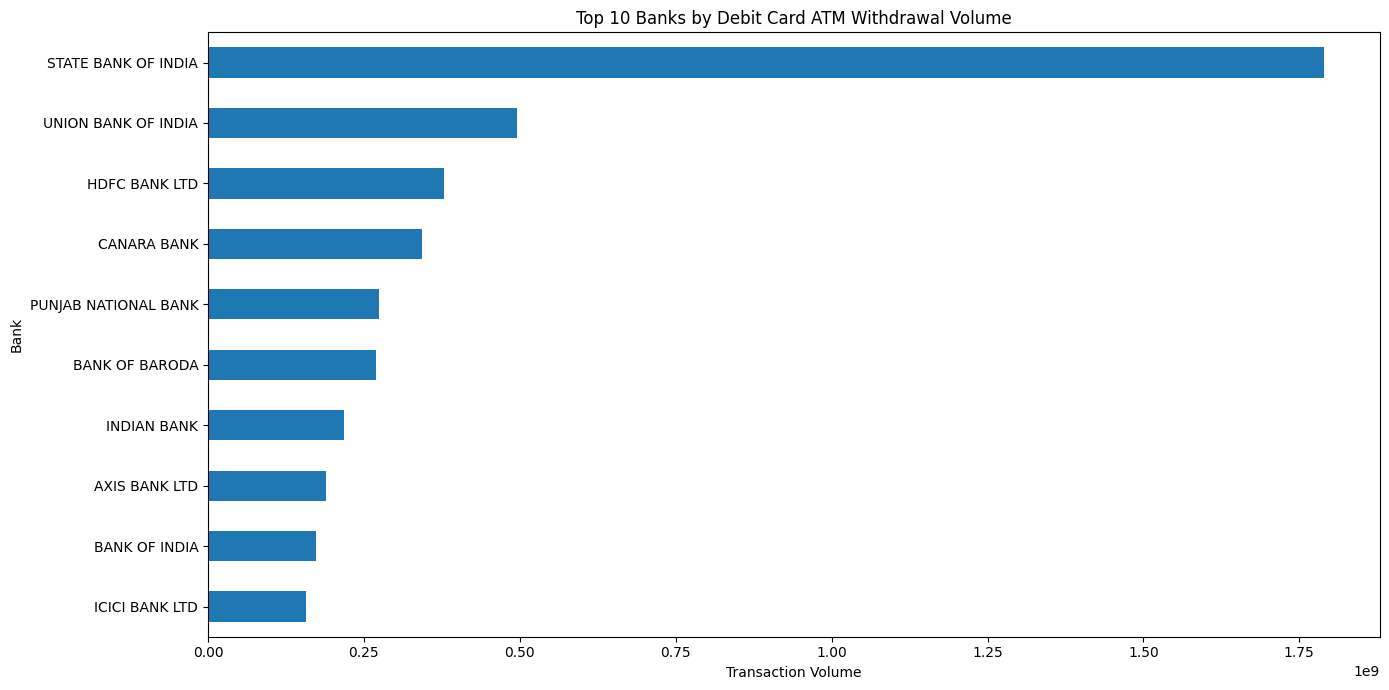


✓ Bank-wise performance visualization completed.


In [27]:
plt.figure(figsize=(14, 7))

top_10_atm["Debit_ATM_Volume"].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Banks by Debit Card ATM Withdrawal Volume")
plt.xlabel("Transaction Volume")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()

print("\n✓ Bank-wise performance visualization completed.")

In [28]:
print("=" * 90)
print("CREDIT CARD - PAYMENT CHANNEL ANALYSIS")
print("=" * 90)

credit_channel_volume = df[
    [
        "Credit Card - Card Payments - PoS - Volume (in actuals)",
        "Credit Card - Card Payments - Online (e-com) - Volume (in actuals)",
        "Credit Card - Card Payments - Others - Volume (in actuals)",
        "Credit Card - Cash Withdrawal - ATM - Volume (in actuals)"
    ]
].sum()

credit_channel_volume.index = [
    "PoS",
    "Online (E-commerce)",
    "Others",
    "ATM Cash Withdrawal"
]

display(credit_channel_volume.to_frame("Transaction Volume"))

print("\n✓ Credit card channel volume calculated.")

CREDIT CARD - PAYMENT CHANNEL ANALYSIS


,Transaction Volume
PoS,2868395345
Online (E-commerce),2813074212
Others,17492988
ATM Cash Withdrawal,8274309



✓ Credit card channel volume calculated.


In [29]:
print("=" * 90)
print("DEBIT CARD - PAYMENT CHANNEL ANALYSIS")
print("=" * 90)

debit_channel_volume = df[
    [
        "Debit Card - Card Payments - PoS - Volume (in actuals)",
        "Debit Card - Card Payments - Online (e-com) - Volume (in actuals)",
        "Debit Card - Card Payments - Others - Volume (in actuals)",
        "Debit Card - Cash Withdrawal - ATM - Volume (in actuals)",
        "Debit Card - Cash Withdrawal - PoS - Volume (in actuals)"
    ]
].sum()

debit_channel_volume.index = [
    "PoS",
    "Online (E-commerce)",
    "Others",
    "ATM Cash Withdrawal",
    "PoS Cash Withdrawal"
]

display(debit_channel_volume.to_frame("Transaction Volume"))

print("\n✓ Debit card channel volume calculated.")

DEBIT CARD - PAYMENT CHANNEL ANALYSIS


,Transaction Volume
PoS,999971898
Online (E-commerce),334588609
Others,1013147
ATM Cash Withdrawal,5471153661
PoS Cash Withdrawal,168700



✓ Debit card channel volume calculated.


In [30]:
print("=" * 90)
print("CREDIT CARD VS DEBIT CARD CHANNEL COMPARISON")
print("=" * 90)

comparison = pd.DataFrame({
    "Credit Card": [
        df["Credit Card - Card Payments - PoS - Volume (in actuals)"].sum(),
        df["Credit Card - Card Payments - Online (e-com) - Volume (in actuals)"].sum(),
        df["Credit Card - Card Payments - Others - Volume (in actuals)"].sum(),
        df["Credit Card - Cash Withdrawal - ATM - Volume (in actuals)"].sum()
    ],
    "Debit Card": [
        df["Debit Card - Card Payments - PoS - Volume (in actuals)"].sum(),
        df["Debit Card - Card Payments - Online (e-com) - Volume (in actuals)"].sum(),
        df["Debit Card - Card Payments - Others - Volume (in actuals)"].sum(),
        df["Debit Card - Cash Withdrawal - ATM - Volume (in actuals)"].sum()
    ]
}, index=[
    "PoS",
    "Online (E-commerce)",
    "Others",
    "ATM Cash Withdrawal"
])

display(comparison)

print("\n✓ Credit vs debit channel comparison completed.")

CREDIT CARD VS DEBIT CARD CHANNEL COMPARISON


,Credit Card,Debit Card
PoS,2868395345,999971898
Online (E-commerce),2813074212,334588609
Others,17492988,1013147
ATM Cash Withdrawal,8274309,5471153661



✓ Credit vs debit channel comparison completed.


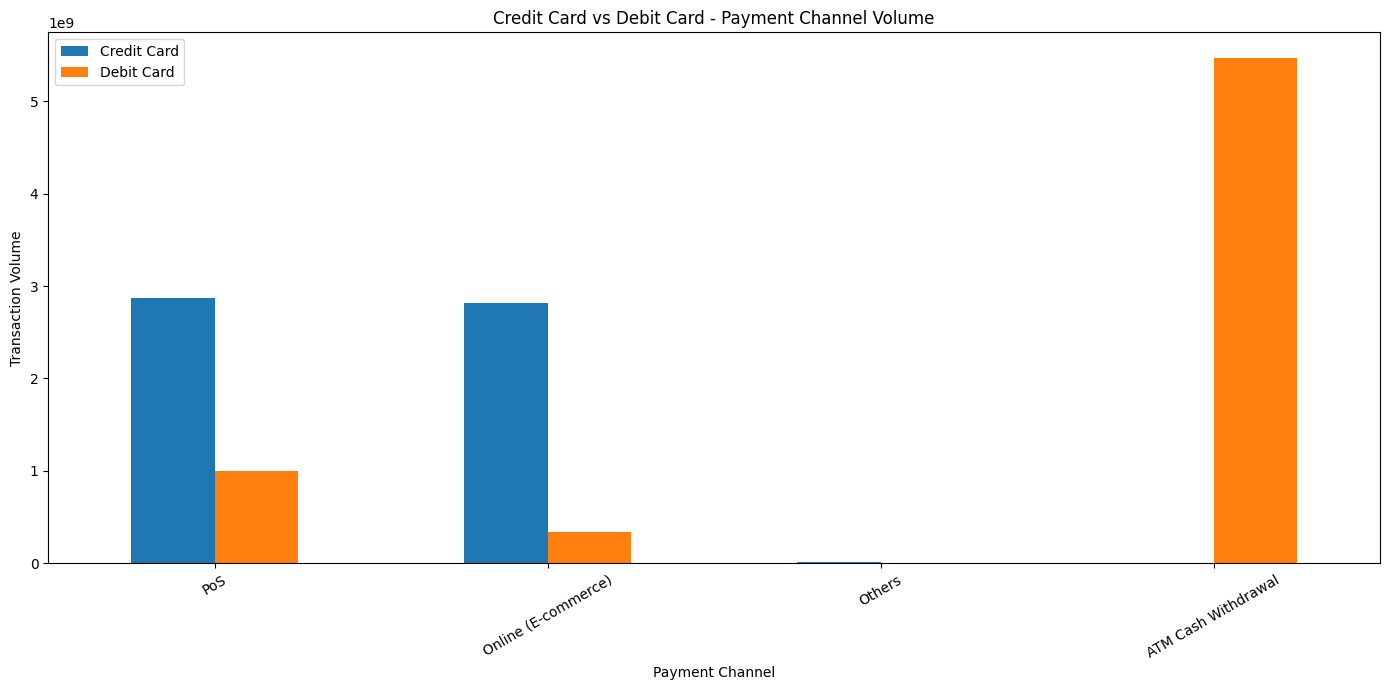


✓ Payment channel visualization completed.


In [31]:
comparison.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Credit Card vs Debit Card - Payment Channel Volume")
plt.xlabel("Payment Channel")
plt.ylabel("Transaction Volume")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("\n✓ Payment channel visualization completed.")

In [32]:
print("=" * 90)
print("PAYMENT CHANNEL CONTRIBUTION (%)")
print("=" * 90)

channel_percentage = comparison.div(
    comparison.sum(axis=0),
    axis=1
) * 100

display(channel_percentage.round(2))

print("\n✓ Payment channel contribution analysis completed.")

PAYMENT CHANNEL CONTRIBUTION (%)


,Credit Card,Debit Card
PoS,50.26,14.69
Online (E-commerce),49.29,4.92
Others,0.31,0.01
ATM Cash Withdrawal,0.14,80.38



✓ Payment channel contribution analysis completed.


In [33]:
print("=" * 90)
print("CREDIT CARD VS DEBIT CARD ANALYSIS")
print("=" * 90)

credit_volume = df[
    [
        "Credit Card - Card Payments - PoS - Volume (in actuals)",
        "Credit Card - Card Payments - Online (e-com) - Volume (in actuals)",
        "Credit Card - Card Payments - Others - Volume (in actuals)",
        "Credit Card - Cash Withdrawal - ATM - Volume (in actuals)"
    ]
].sum().sum()

debit_volume = df[
    [
        "Debit Card - Card Payments - PoS - Volume (in actuals)",
        "Debit Card - Card Payments - Online (e-com) - Volume (in actuals)",
        "Debit Card - Card Payments - Others - Volume (in actuals)",
        "Debit Card - Cash Withdrawal - ATM - Volume (in actuals)",
        "Debit Card - Cash Withdrawal - PoS - Volume (in actuals)"
    ]
].sum().sum()

card_volume = pd.Series({
    "Credit Card": credit_volume,
    "Debit Card": debit_volume
})

display(card_volume.to_frame("Total Transaction Volume"))

print("\n✓ Overall card transaction volume calculated.")

CREDIT CARD VS DEBIT CARD ANALYSIS


,Total Transaction Volume
Credit Card,5707236854
Debit Card,6806896015



✓ Overall card transaction volume calculated.


In [34]:
credit_value = df[
    [
        "Credit Card - Card Payments - PoS - Value (in Rs'000)",
        "Credit Card - Card Payments - Online (e-com) - Value (in Rs'000)",
        "Credit Card - Card Payments - Others - Value (in Rs'000)",
        "Credit Card - Cash Withdrawal - ATM - Value (in Rs'000)"
    ]
].sum().sum()

debit_value = df[
    [
        "Debit Card - Card Payments - PoS - Value (in Rs'000)",
        "Debit Card - Card Payments - Online (e-com) - Value (in Rs'000)",
        "Debit Card - Card Payments - Others - Value (in Rs'000)",
        "Debit Card - Cash Withdrawal - ATM - Value (in Rs'000)",
        "Debit Card - Cash Withdrawal - PoS - Value (in Rs'000)"
    ]
].sum().sum()

card_value = pd.Series({
    "Credit Card": credit_value,
    "Debit Card": debit_value
})

display(card_value.to_frame("Total Transaction Value (Rs'000)"))

print("\n✓ Overall card transaction value calculated.")

,Total Transaction Value (Rs'000)
Credit Card,"23,239,789,962.05"
Debit Card,"33,371,740,382.07"



✓ Overall card transaction value calculated.


In [35]:
card_infrastructure = pd.Series({
    "Credit Cards": df["Infrastructure - Credit Cards"].sum(),
    "Debit Cards": df["Infrastructure - Debit Cards"].sum()
})

display(card_infrastructure.to_frame("Total Cards"))

print("\n✓ Card infrastructure comparison completed.")

,Total Cards
Credit Cards,1343267030
Debit Cards,12108840112



✓ Card infrastructure comparison completed.


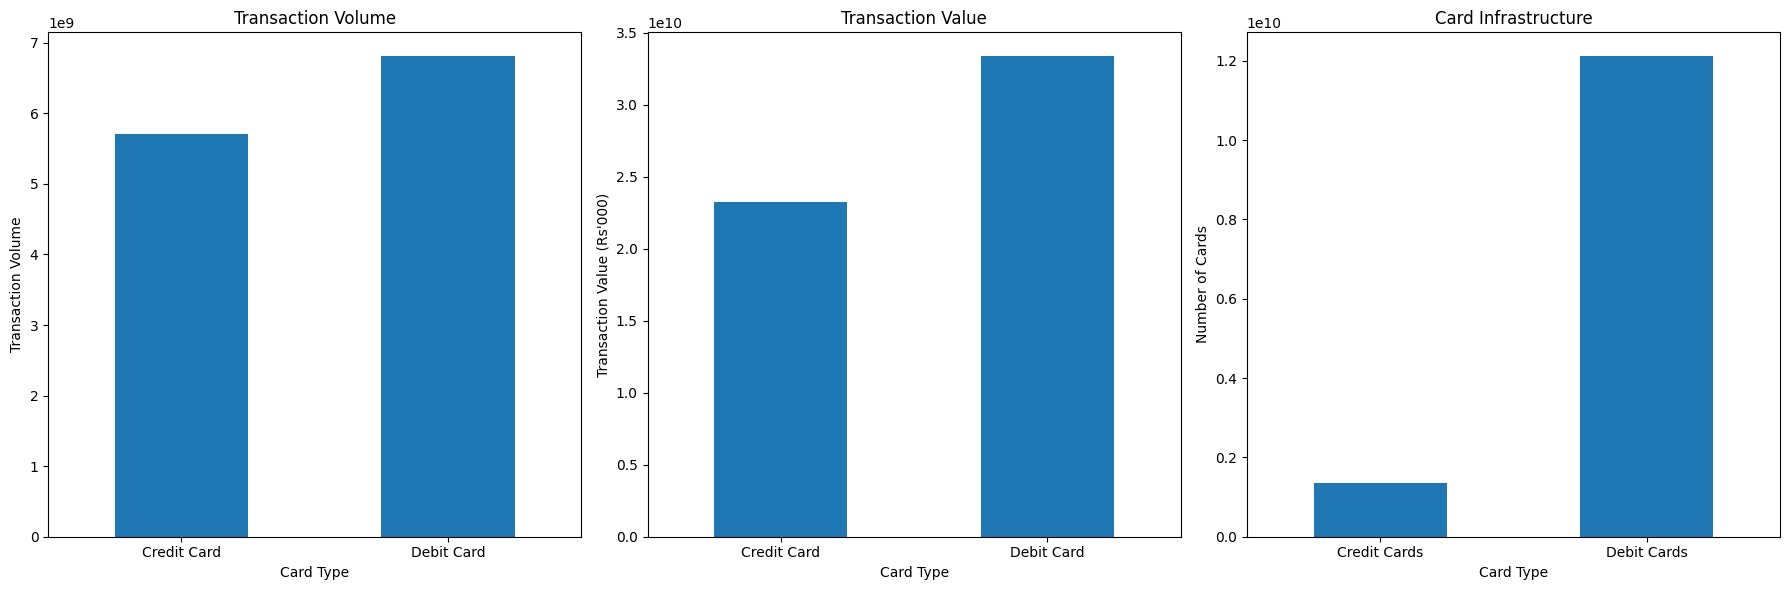


✓ Credit vs debit comparison visualization completed.


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

card_volume.plot(
    kind="bar",
    ax=axes[0],
    title="Transaction Volume"
)

card_value.plot(
    kind="bar",
    ax=axes[1],
    title="Transaction Value"
)

card_infrastructure.plot(
    kind="bar",
    ax=axes[2],
    title="Card Infrastructure"
)

for ax in axes:
    ax.set_xlabel("Card Type")
    ax.tick_params(axis="x", rotation=0)

axes[0].set_ylabel("Transaction Volume")
axes[1].set_ylabel("Transaction Value (Rs'000)")
axes[2].set_ylabel("Number of Cards")

plt.tight_layout()
plt.show()

print("\n✓ Credit vs debit comparison visualization completed.")

,Credit_Card_Volume,Debit_Card_Volume
Date,,
2025-01-01,217743317,91091391
2025-02-01,199995593,80342355
2025-03-01,230266329,89581561
2025-04-01,228140764,87530236
2025-05-01,235914154,86156629
2025-06-01,233869565,81289624
2025-07-01,243275291,83219175
2025-08-01,250162542,84359478
2025-09-01,241614615,77755830


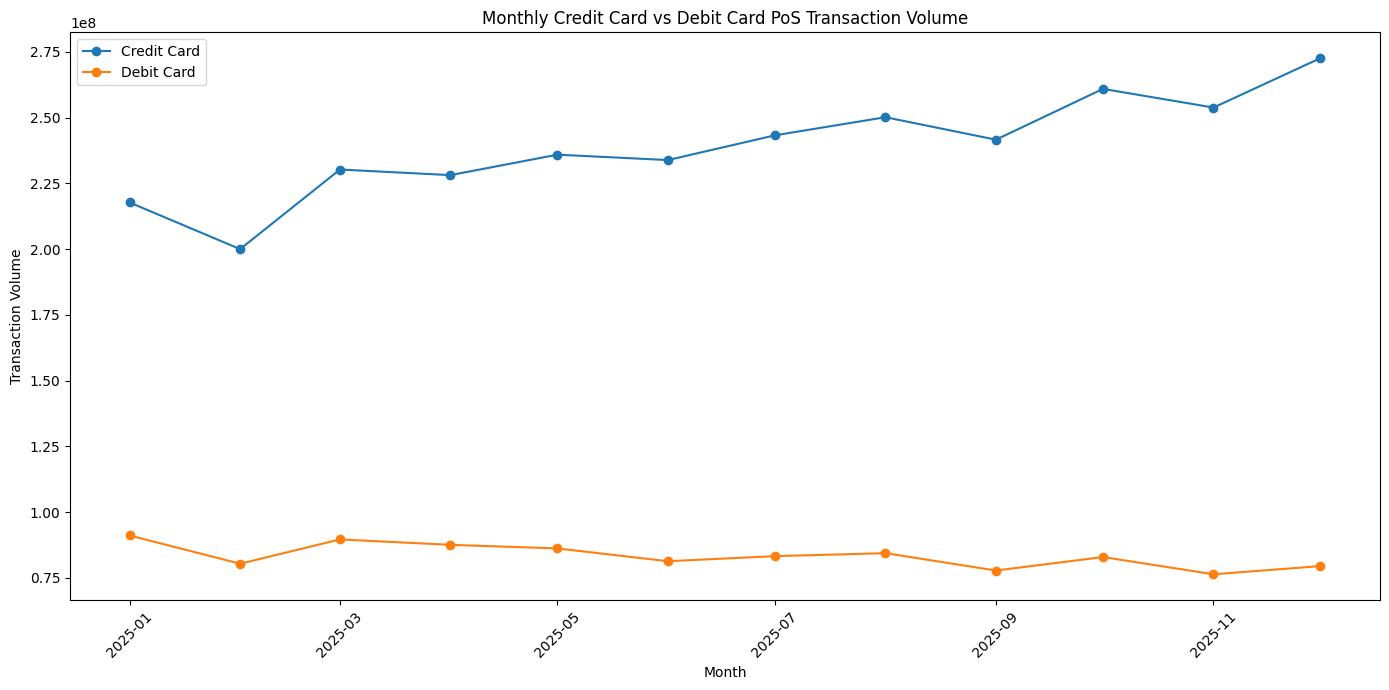


✓ Monthly credit vs debit analysis completed.


In [37]:
monthly_card_volume = df.groupby("Date").agg(
    Credit_Card_Volume=(
        "Credit Card - Card Payments - PoS - Volume (in actuals)",
        "sum"
    ),
    Debit_Card_Volume=(
        "Debit Card - Card Payments - PoS - Volume (in actuals)",
        "sum"
    )
)

display(monthly_card_volume)

plt.figure(figsize=(14, 7))

plt.plot(
    monthly_card_volume.index,
    monthly_card_volume["Credit_Card_Volume"],
    marker="o",
    label="Credit Card"
)

plt.plot(
    monthly_card_volume.index,
    monthly_card_volume["Debit_Card_Volume"],
    marker="o",
    label="Debit Card"
)

plt.title("Monthly Credit Card vs Debit Card PoS Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Transaction Volume")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("\n✓ Monthly credit vs debit analysis completed.")

In [38]:
print("=" * 90)
print("ATM & DIGITAL INFRASTRUCTURE ANALYSIS")
print("=" * 90)

infrastructure_cols = [
    "Infrastructure - ATMs & CRMs - On-site",
    "Infrastructure - ATMs & CRMs - Off-site",
    "Infrastructure - PoS",
    "Infrastructure - Micro ATMs",
    "Infrastructure - Bharat QR Codes",
    "Infrastructure - UPI QR Codes",
    "Infrastructure - Credit Cards",
    "Infrastructure - Debit Cards"
]

infrastructure_summary = df[infrastructure_cols].sum()

infrastructure_summary.index = [
    "On-site ATMs & CRMs",
    "Off-site ATMs & CRMs",
    "PoS",
    "Micro ATMs",
    "Bharat QR Codes",
    "UPI QR Codes",
    "Credit Cards",
    "Debit Cards"
]

display(
    infrastructure_summary
    .sort_values(ascending=False)
    .to_frame("Total Infrastructure")
)

print("\n✓ Infrastructure summary calculated.")

ATM & DIGITAL INFRASTRUCTURE ANALYSIS


,Total Infrastructure
Debit Cards,"12,108,840,112.00"
UPI QR Codes,"8,229,812,777.50"
Credit Cards,"1,343,267,030.00"
PoS,"137,845,809.00"
Bharat QR Codes,"76,889,626.00"
Micro ATMs,"17,539,018.00"
On-site ATMs & CRMs,"1,584,833.00"
Off-site ATMs & CRMs,"947,733.00"



✓ Infrastructure summary calculated.


In [39]:
print("=" * 90)
print("INFRASTRUCTURE BY BANK CATEGORY")
print("=" * 90)

category_infrastructure = df.groupby("Bank Category")[infrastructure_cols].sum()

display(category_infrastructure)

print("\n✓ Category-wise infrastructure calculated.")

INFRASTRUCTURE BY BANK CATEGORY


,Infrastructure - ATMs & CRMs - On-site,Infrastructure - ATMs & CRMs - Off-site,Infrastructure - PoS,Infrastructure - Micro ATMs,Infrastructure - Bharat QR Codes,Infrastructure - UPI QR Codes,Infrastructure - Credit Cards,Infrastructure - Debit Cards
Bank Category,,,,,,,,
Foreign Banks,6975,5029,196438,1063,12,"104,844.00",54518178,52414157
Payment Banks,0,0,0,13242144,0,"48,482,326.00",0,930472369
Private Sector Banks,569676,316700,114787927,2102562,47228796,"7,895,833,567.50",952123304,3059834646
Public Sector Banks,970355,625664,22828886,2108910,29001078,"267,713,178.00",322185706,7688992388
Small Finance Banks,37827,340,32558,84339,659740,"17,678,862.00",14439842,377126552



✓ Category-wise infrastructure calculated.


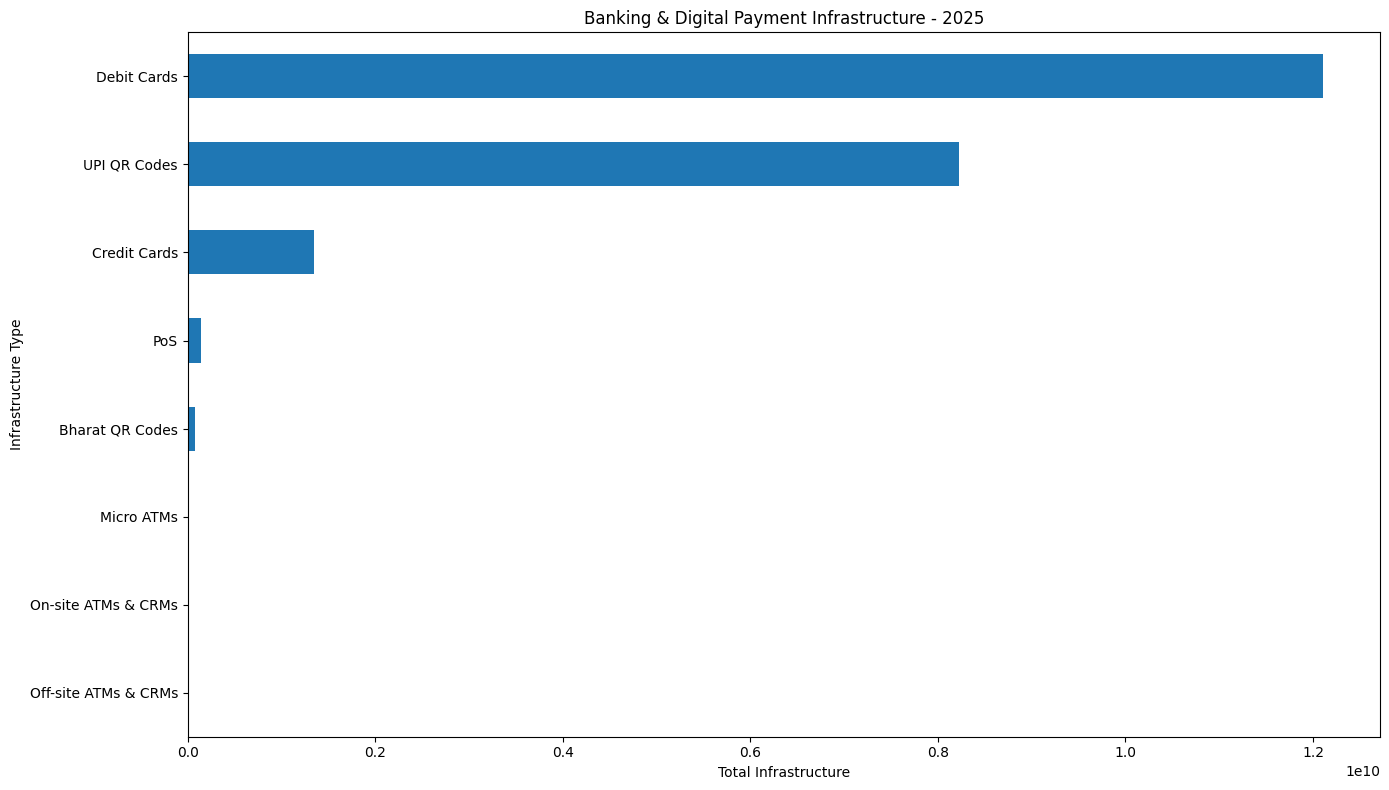


✓ Infrastructure visualization completed.


In [40]:
plt.figure(figsize=(14, 8))

infrastructure_summary.sort_values().plot(
    kind="barh"
)

plt.title("Banking & Digital Payment Infrastructure - 2025")
plt.xlabel("Total Infrastructure")
plt.ylabel("Infrastructure Type")
plt.tight_layout()
plt.show()

print("\n✓ Infrastructure visualization completed.")

ATM INFRASTRUCTURE ANALYSIS


,Total ATM Infrastructure
On-site ATMs & CRMs,1584833
Off-site ATMs & CRMs,947733


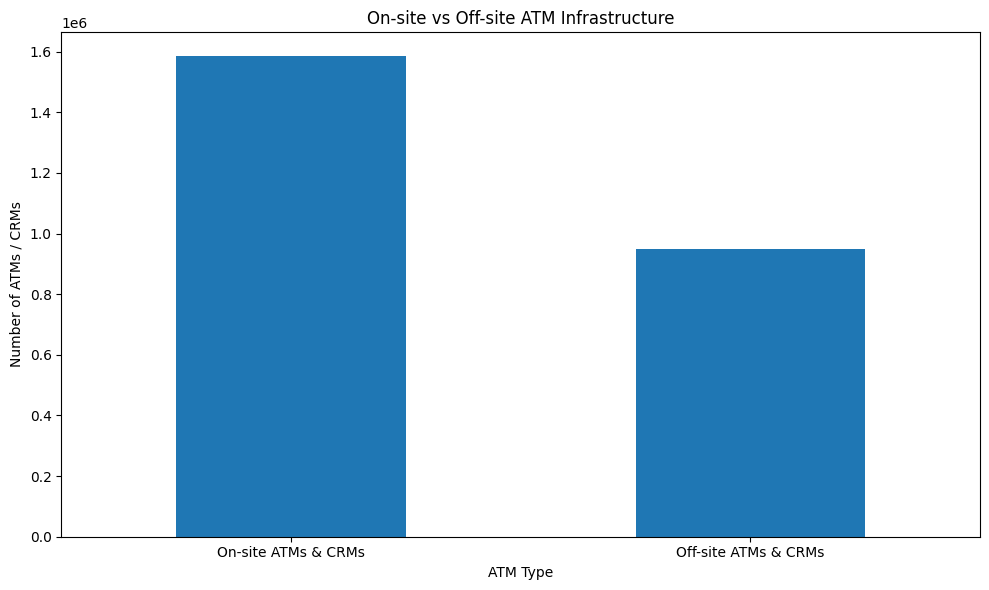


✓ ATM infrastructure analysis completed.


In [41]:
print("=" * 90)
print("ATM INFRASTRUCTURE ANALYSIS")
print("=" * 90)

atm_summary = pd.Series({
    "On-site ATMs & CRMs":
        df["Infrastructure - ATMs & CRMs - On-site"].sum(),
    "Off-site ATMs & CRMs":
        df["Infrastructure - ATMs & CRMs - Off-site"].sum()
})

display(atm_summary.to_frame("Total ATM Infrastructure"))

plt.figure(figsize=(10, 6))

atm_summary.plot(
    kind="bar"
)

plt.title("On-site vs Off-site ATM Infrastructure")
plt.xlabel("ATM Type")
plt.ylabel("Number of ATMs / CRMs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✓ ATM infrastructure analysis completed.")

DIGITAL PAYMENT INFRASTRUCTURE ANALYSIS


,Total Infrastructure
UPI QR Codes,"8,229,812,777.50"
PoS,"137,845,809.00"
Bharat QR Codes,"76,889,626.00"
Micro ATMs,"17,539,018.00"


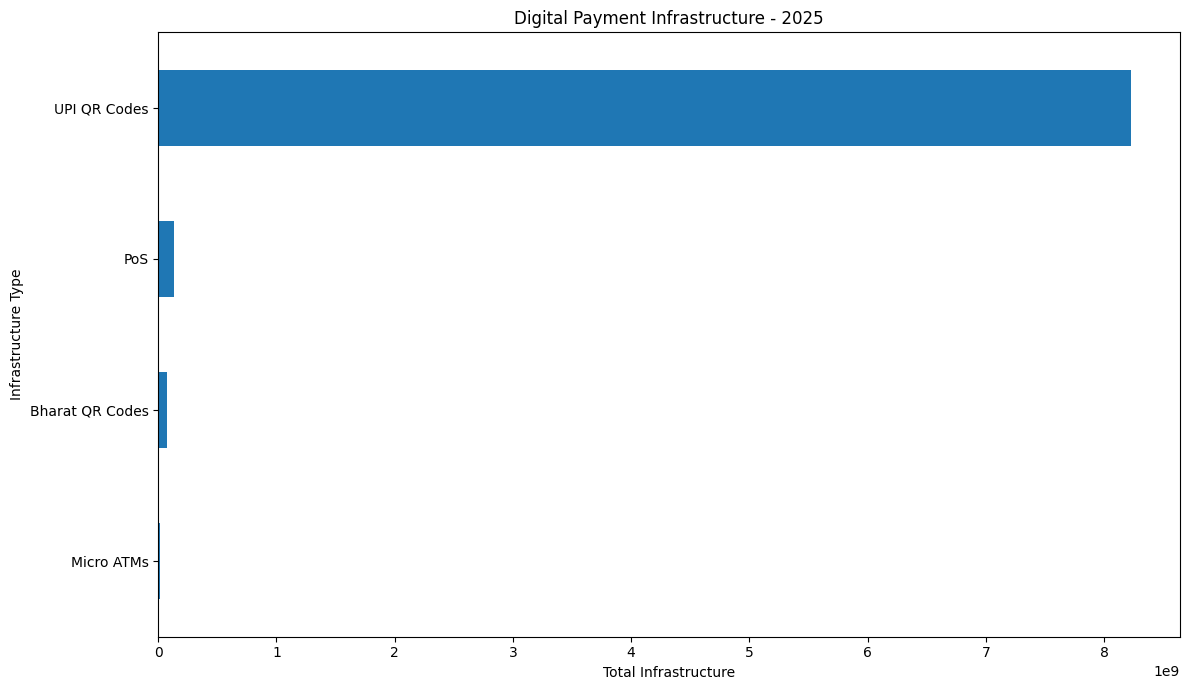


✓ Digital infrastructure analysis completed.


In [42]:
print("=" * 90)
print("DIGITAL PAYMENT INFRASTRUCTURE ANALYSIS")
print("=" * 90)

digital_summary = pd.Series({
    "PoS": df["Infrastructure - PoS"].sum(),
    "Micro ATMs": df["Infrastructure - Micro ATMs"].sum(),
    "Bharat QR Codes": df["Infrastructure - Bharat QR Codes"].sum(),
    "UPI QR Codes": df["Infrastructure - UPI QR Codes"].sum()
})

display(
    digital_summary
    .sort_values(ascending=False)
    .to_frame("Total Infrastructure")
)

plt.figure(figsize=(12, 7))

digital_summary.sort_values().plot(
    kind="barh"
)

plt.title("Digital Payment Infrastructure - 2025")
plt.xlabel("Total Infrastructure")
plt.ylabel("Infrastructure Type")
plt.tight_layout()
plt.show()

print("\n✓ Digital infrastructure analysis completed.")

In [43]:
print("=" * 90)
print("INFRASTRUCTURE–TRANSACTION RELATIONSHIP ANALYSIS")
print("=" * 90)

relationship_cols = {
    "On-site ATMs": "Infrastructure - ATMs & CRMs - On-site",
    "Off-site ATMs": "Infrastructure - ATMs & CRMs - Off-site",
    "PoS": "Infrastructure - PoS",
    "Micro ATMs": "Infrastructure - Micro ATMs",
    "Bharat QR": "Infrastructure - Bharat QR Codes",
    "UPI QR": "Infrastructure - UPI QR Codes",
    "Credit Cards": "Infrastructure - Credit Cards",
    "Debit Cards": "Infrastructure - Debit Cards"
}

transaction_volume_cols = {
    "Credit PoS": "Credit Card - Card Payments - PoS - Volume (in actuals)",
    "Credit Online": "Credit Card - Card Payments - Online (e-com) - Volume (in actuals)",
    "Debit PoS": "Debit Card - Card Payments - PoS - Volume (in actuals)",
    "Debit Online": "Debit Card - Card Payments - Online (e-com) - Volume (in actuals)",
    "Debit ATM": "Debit Card - Cash Withdrawal - ATM - Volume (in actuals)"
}

infra_df = df[list(relationship_cols.values())].copy()
infra_df.columns = relationship_cols.keys()

volume_df = df[list(transaction_volume_cols.values())].copy()
volume_df.columns = transaction_volume_cols.keys()

infra_volume_corr = pd.concat(
    [infra_df, volume_df],
    axis=1
).corr().loc[
    infra_df.columns,
    volume_df.columns
]

display(infra_volume_corr.round(2))

print("\n✓ Infrastructure vs transaction volume correlation calculated.")

INFRASTRUCTURE–TRANSACTION RELATIONSHIP ANALYSIS


,Credit PoS,Credit Online,Debit PoS,Debit Online,Debit ATM
On-site ATMs,0.56,0.76,0.95,0.88,0.94
Off-site ATMs,0.48,0.72,0.98,0.82,0.95
PoS,0.65,0.77,0.48,0.63,0.40
Micro ATMs,-0.04,-0.03,0.01,-0.03,0.01
Bharat QR,0.91,0.70,0.62,0.89,0.55
UPI QR,0.15,0.04,-0.00,0.00,-0.01
Credit Cards,0.88,0.93,0.72,0.92,0.62
Debit Cards,0.42,0.63,0.95,0.78,0.96



✓ Infrastructure vs transaction volume correlation calculated.


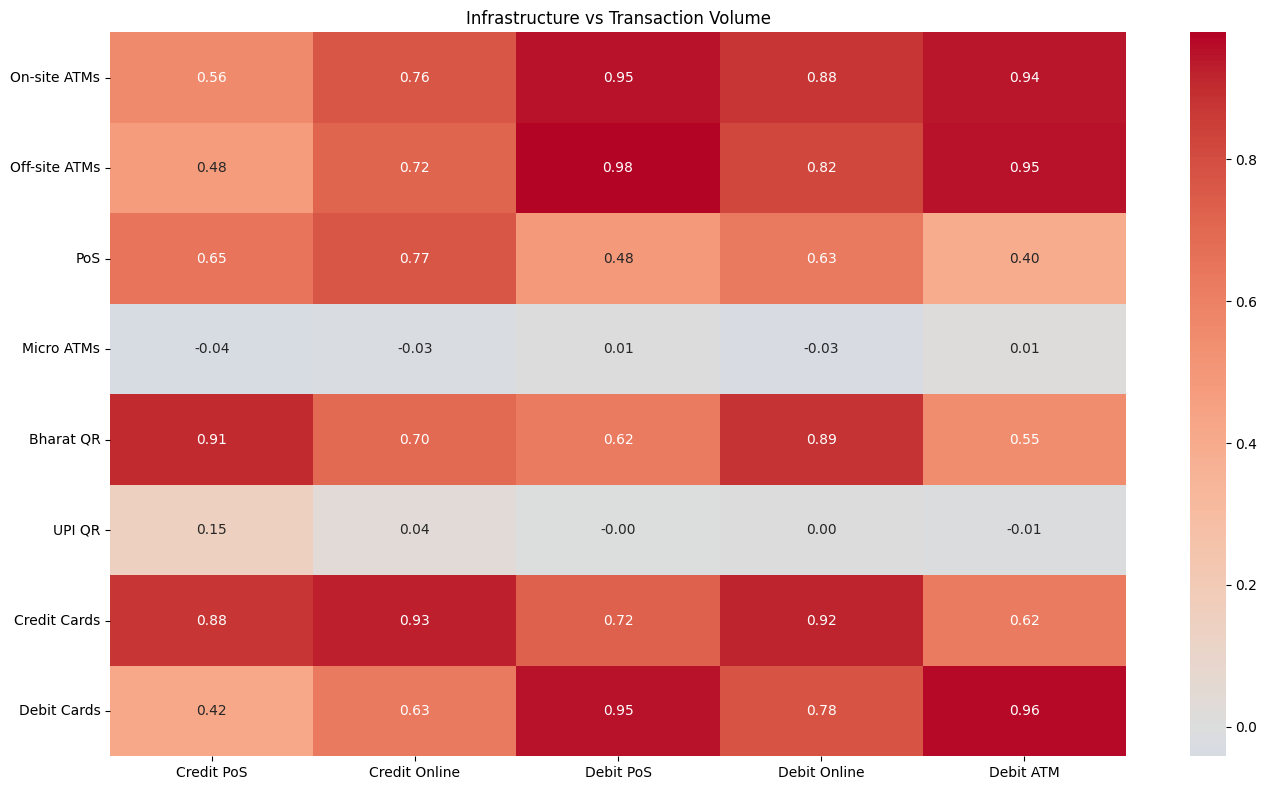


✓ Infrastructure–transaction relationship heatmap generated.


In [44]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    infra_volume_corr,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)

plt.title("Infrastructure vs Transaction Volume")
plt.tight_layout()
plt.show()

print("\n✓ Infrastructure–transaction relationship heatmap generated.")

In [45]:
print("=" * 90)
print("INFRASTRUCTURE–TRANSACTION VALUE RELATIONSHIP")
print("=" * 90)

transaction_value_cols = {
    "Credit PoS": "Credit Card - Card Payments - PoS - Value (in Rs'000)",
    "Credit Online": "Credit Card - Card Payments - Online (e-com) - Value (in Rs'000)",
    "Debit PoS": "Debit Card - Card Payments - PoS - Value (in Rs'000)",
    "Debit Online": "Debit Card - Card Payments - Online (e-com) - Value (in Rs'000)",
    "Debit ATM": "Debit Card - Cash Withdrawal - ATM - Value (in Rs'000)"
}

value_df = df[list(transaction_value_cols.values())].copy()
value_df.columns = transaction_value_cols.keys()

infra_value_corr = pd.concat(
    [infra_df, value_df],
    axis=1
).corr().loc[
    infra_df.columns,
    value_df.columns
]

display(infra_value_corr.round(2))

print("\n✓ Infrastructure vs transaction value correlation calculated.")

INFRASTRUCTURE–TRANSACTION VALUE RELATIONSHIP


,Credit PoS,Credit Online,Debit PoS,Debit Online,Debit ATM
On-site ATMs,0.70,0.71,0.96,0.77,0.95
Off-site ATMs,0.63,0.62,0.95,0.67,0.98
PoS,0.77,0.76,0.57,0.69,0.45
Micro ATMs,-0.04,-0.04,-0.01,-0.04,0.01
Bharat QR,0.90,0.87,0.74,0.92,0.60
UPI QR,0.11,0.04,0.01,0.02,-0.00
Credit Cards,0.98,0.97,0.83,0.96,0.69
Debit Cards,0.55,0.55,0.91,0.62,0.96



✓ Infrastructure vs transaction value correlation calculated.


In [46]:
print("=" * 90)
print("STRONGEST INFRASTRUCTURE–TRANSACTION RELATIONSHIPS")
print("=" * 90)

relationships = []

for infrastructure in infra_volume_corr.index:
    for transaction in infra_volume_corr.columns:
        relationships.append({
            "Infrastructure": infrastructure,
            "Transaction Channel": transaction,
            "Correlation": infra_volume_corr.loc[infrastructure, transaction]
        })

relationship_table = pd.DataFrame(relationships)

relationship_table["Absolute Correlation"] = (
    relationship_table["Correlation"].abs()
)

relationship_table = relationship_table.sort_values(
    "Absolute Correlation",
    ascending=False
)

display(
    relationship_table.head(15).round(3)
)

print("\n✓ Strongest relationships identified.")

STRONGEST INFRASTRUCTURE–TRANSACTION RELATIONSHIPS


,Infrastructure,Transaction Channel,Correlation,Absolute Correlation
7,Off-site ATMs,Debit PoS,0.98,0.98
39,Debit Cards,Debit ATM,0.96,0.96
9,Off-site ATMs,Debit ATM,0.95,0.95
2,On-site ATMs,Debit PoS,0.95,0.95
37,Debit Cards,Debit PoS,0.95,0.95
4,On-site ATMs,Debit ATM,0.94,0.94
31,Credit Cards,Credit Online,0.93,0.93
33,Credit Cards,Debit Online,0.92,0.92
20,Bharat QR,Credit PoS,0.91,0.91
23,Bharat QR,Debit Online,0.89,0.89



✓ Strongest relationships identified.


In [47]:
print("=" * 90)
print("FINAL EDA SUMMARY")
print("=" * 90)

print("\nDATASET OVERVIEW")
print("-" * 90)

print(f"Total records              : {len(df):,}")
print(f"Total columns              : {df.shape[1]:,}")
print(f"Unique banks               : {df['Bank Name'].nunique():,}")
print(f"Bank categories            : {df['Bank Category'].nunique():,}")
print(f"Months covered             : {df['Month'].nunique():,}")
print(f"Missing values             : {df.isna().sum().sum():,}")
print(f"Duplicate records          : {df.duplicated().sum():,}")

print("\n✓ Dataset-level summary completed.")

FINAL EDA SUMMARY

DATASET OVERVIEW
------------------------------------------------------------------------------------------
Total records              : 768
Total columns              : 35
Unique banks               : 65
Bank categories            : 5
Months covered             : 12
Missing values             : 0
Duplicate records          : 0

✓ Dataset-level summary completed.


In [49]:
# ============================================================================
# MONTHLY TRANSACTION INSIGHTS
# ============================================================================

print("=" * 90)
print("MONTHLY TRANSACTION INSIGHTS")
print("=" * 90)

# --------------------------------------------------------------------------
# Define transaction volume columns
# --------------------------------------------------------------------------

volume_columns = [
    'Credit Card - Card Payments - PoS - Volume (in actuals)',
    'Credit Card - Card Payments - Online (e-com) - Volume (in actuals)',
    'Credit Card - Cash Withdrawal - ATM - Volume (in actuals)',
    'Debit Card - Card Payments - PoS - Volume (in actuals)',
    'Debit Card - Card Payments - Online (e-com) - Volume (in actuals)',
    'Debit Card - Cash Withdrawal - ATM - Volume (in actuals)'
]

# --------------------------------------------------------------------------
# Calculate monthly transaction volume
# --------------------------------------------------------------------------

monthly_volume = df.groupby('Date')[volume_columns].sum()

# Total transaction volume across all channels
monthly_volume_total = monthly_volume.sum(axis=1)

# --------------------------------------------------------------------------
# Highest and lowest volume months
# --------------------------------------------------------------------------

highest_volume_month = monthly_volume_total.idxmax()
highest_volume = monthly_volume_total.max()

lowest_volume_month = monthly_volume_total.idxmin()
lowest_volume = monthly_volume_total.min()

# --------------------------------------------------------------------------
# Average monthly transaction volume
# --------------------------------------------------------------------------

average_monthly_volume = monthly_volume_total.mean()

# --------------------------------------------------------------------------
# Percentage difference between highest and lowest
# --------------------------------------------------------------------------

volume_difference_pct = (
    (highest_volume - lowest_volume) / lowest_volume
) * 100

# --------------------------------------------------------------------------
# Display results
# --------------------------------------------------------------------------

print("\nMONTHLY TRANSACTION VOLUME SUMMARY")
print("-" * 90)

print(f"Highest transaction volume month : "
      f"{highest_volume_month.strftime('%B %Y')}")
print(f"Highest transaction volume       : "
      f"{highest_volume:,.0f}")

print(f"\nLowest transaction volume month  : "
      f"{lowest_volume_month.strftime('%B %Y')}")
print(f"Lowest transaction volume        : "
      f"{lowest_volume:,.0f}")

print(f"\nAverage monthly transaction volume : "
      f"{average_monthly_volume:,.0f}")

print(f"\nDifference between highest and lowest month : "
      f"{volume_difference_pct:.2f}%")

# --------------------------------------------------------------------------
# Channel-wise totals
# --------------------------------------------------------------------------

channel_totals = monthly_volume.sum().sort_values(ascending=False)

print("\nCHANNEL-WISE TOTAL TRANSACTION VOLUME")
print("-" * 90)

for channel, value in channel_totals.items():
    print(f"{channel:<75} {value:,.0f}")

# --------------------------------------------------------------------------
# Highest-volume channel
# --------------------------------------------------------------------------

highest_channel = channel_totals.idxmax()
highest_channel_value = channel_totals.max()

print("\nHIGHEST VOLUME CHANNEL")
print("-" * 90)

print(f"Channel : {highest_channel}")
print(f"Total transactions : {highest_channel_value:,.0f}")

# --------------------------------------------------------------------------
# Monthly ranking
# --------------------------------------------------------------------------

monthly_ranking = monthly_volume_total.sort_values(ascending=False)

print("\nMONTHLY TRANSACTION VOLUME RANKING")
print("-" * 90)

for i, (date, value) in enumerate(monthly_ranking.items(), start=1):
    print(f"{i:2}. {date.strftime('%B')} : {value:,.0f}")

print("\n✓ Monthly transaction insights completed.")

MONTHLY TRANSACTION INSIGHTS

MONTHLY TRANSACTION VOLUME SUMMARY
------------------------------------------------------------------------------------------
Highest transaction volume month : October 2025
Highest transaction volume       : 1,090,104,935

Lowest transaction volume month  : February 2025
Lowest transaction volume        : 952,497,413

Average monthly transaction volume : 1,041,288,170

Difference between highest and lowest month : 14.45%

CHANNEL-WISE TOTAL TRANSACTION VOLUME
------------------------------------------------------------------------------------------
Debit Card - Cash Withdrawal - ATM - Volume (in actuals)                    5,471,153,661
Credit Card - Card Payments - PoS - Volume (in actuals)                     2,868,395,345
Credit Card - Card Payments - Online (e-com) - Volume (in actuals)          2,813,074,212
Debit Card - Card Payments - PoS - Volume (in actuals)                      999,971,898
Debit Card - Card Payments - Online (e-com) - Volume (in

BANK CATEGORY ANALYSIS

TRANSACTION VOLUME BY BANK CATEGORY
------------------------------------------------------------------------------------------
                      Credit Card - Card Payments - PoS - Volume (in actuals)  Credit Card - Card Payments - Online (e-com) - Volume (in actuals)  Credit Card - Cash Withdrawal - ATM - Volume (in actuals)  Debit Card - Card Payments - PoS - Volume (in actuals)  Debit Card - Card Payments - Online (e-com) - Volume (in actuals)  Debit Card - Cash Withdrawal - ATM - Volume (in actuals)  Total Transaction Volume
Bank Category                                                                                                                                                                                                                                                                                                                                                                                                              
Private Sector Banks     

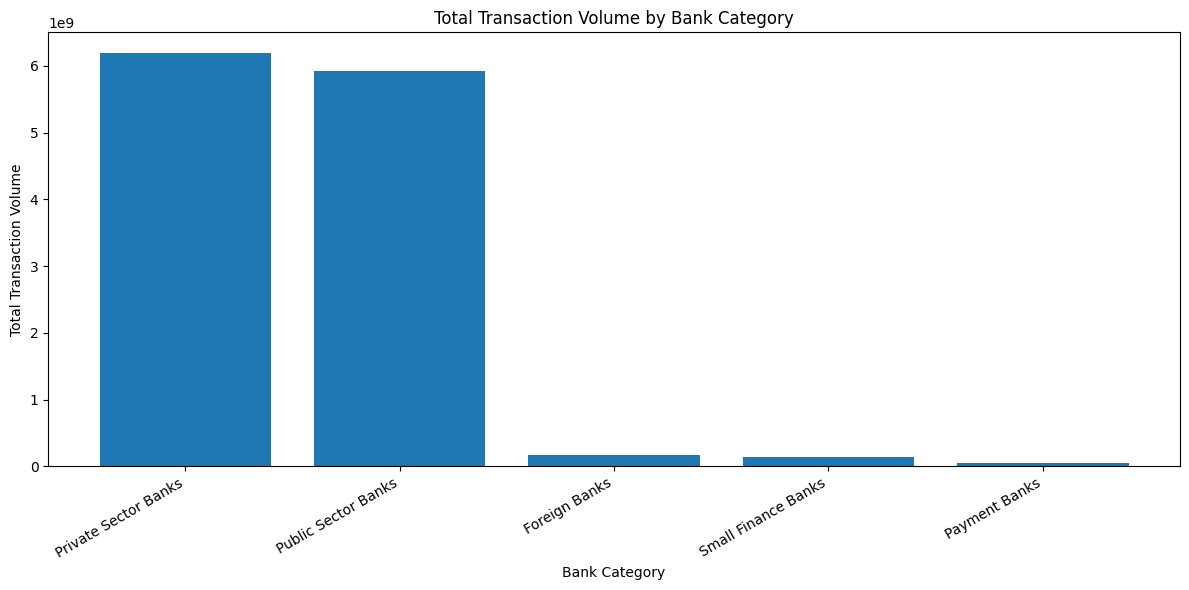


✓ Bank category analysis completed.


In [50]:
# ============================================================================
# BANK CATEGORY ANALYSIS
# ============================================================================

print("=" * 90)
print("BANK CATEGORY ANALYSIS")
print("=" * 90)

# --------------------------------------------------------------------------
# Transaction volume columns
# --------------------------------------------------------------------------

volume_columns = [
    'Credit Card - Card Payments - PoS - Volume (in actuals)',
    'Credit Card - Card Payments - Online (e-com) - Volume (in actuals)',
    'Credit Card - Cash Withdrawal - ATM - Volume (in actuals)',
    'Debit Card - Card Payments - PoS - Volume (in actuals)',
    'Debit Card - Card Payments - Online (e-com) - Volume (in actuals)',
    'Debit Card - Cash Withdrawal - ATM - Volume (in actuals)'
]

# --------------------------------------------------------------------------
# Aggregate transaction volumes by bank category
# --------------------------------------------------------------------------

category_volume = df.groupby('Bank Category')[volume_columns].sum()

# Total transaction volume for each category
category_volume['Total Transaction Volume'] = category_volume.sum(axis=1)

# Sort by total volume
category_volume = category_volume.sort_values(
    'Total Transaction Volume',
    ascending=False
)

print("\nTRANSACTION VOLUME BY BANK CATEGORY")
print("-" * 90)

print(category_volume.to_string())

# --------------------------------------------------------------------------
# Category-wise bank count
# --------------------------------------------------------------------------

bank_count = df.groupby('Bank Category')['Bank Name'].nunique()

print("\nNUMBER OF BANKS BY CATEGORY")
print("-" * 90)

for category, count in bank_count.items():
    print(f"{category:<30} : {count}")

# --------------------------------------------------------------------------
# Percentage contribution
# --------------------------------------------------------------------------

category_volume['Volume Share (%)'] = (
    category_volume['Total Transaction Volume']
    / category_volume['Total Transaction Volume'].sum()
) * 100

print("\nTRANSACTION VOLUME SHARE")
print("-" * 90)

for category, row in category_volume.iterrows():
    print(
        f"{category:<30} : "
        f"{row['Volume Share (%)']:.2f}%"
    )

# --------------------------------------------------------------------------
# Highest and lowest categories
# --------------------------------------------------------------------------

highest_category = category_volume['Total Transaction Volume'].idxmax()
highest_category_volume = category_volume['Total Transaction Volume'].max()

lowest_category = category_volume['Total Transaction Volume'].idxmin()
lowest_category_volume = category_volume['Total Transaction Volume'].min()

print("\nCATEGORY INSIGHTS")
print("-" * 90)

print(
    f"Highest transaction category : {highest_category}"
)
print(
    f"Highest transaction volume   : "
    f"{highest_category_volume:,.0f}"
)

print(
    f"\nLowest transaction category  : {lowest_category}"
)
print(
    f"Lowest transaction volume    : "
    f"{lowest_category_volume:,.0f}"
)

# --------------------------------------------------------------------------
# Visualization
# --------------------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    category_volume.index,
    category_volume['Total Transaction Volume']
)

plt.title("Total Transaction Volume by Bank Category")
plt.xlabel("Bank Category")
plt.ylabel("Total Transaction Volume")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("\n✓ Bank category analysis completed.")

BANK-WISE TRANSACTION ANALYSIS

TOP 15 BANKS BY TOTAL TRANSACTION VOLUME
------------------------------------------------------------------------------------------
                                              Total Transaction Volume
Bank Name               Bank Category                                 
STATE BANK OF INDIA     Public Sector Banks                 3203952475
HDFC BANK LTD           Private Sector Banks                2070501449
ICICI BANK LTD          Private Sector Banks                1266627553
AXIS BANK LTD           Private Sector Banks                1081115884
UNION BANK OF INDIA     Public Sector Banks                  584340446
BANK OF BARODA          Public Sector Banks                  441302921
CANARA BANK             Public Sector Banks                  435332779
KOTAK MAHINDRA BANK LTD Private Sector Banks                 348831386
PUNJAB NATIONAL BANK    Public Sector Banks                  335880318
INDIAN BANK             Public Sector Banks            

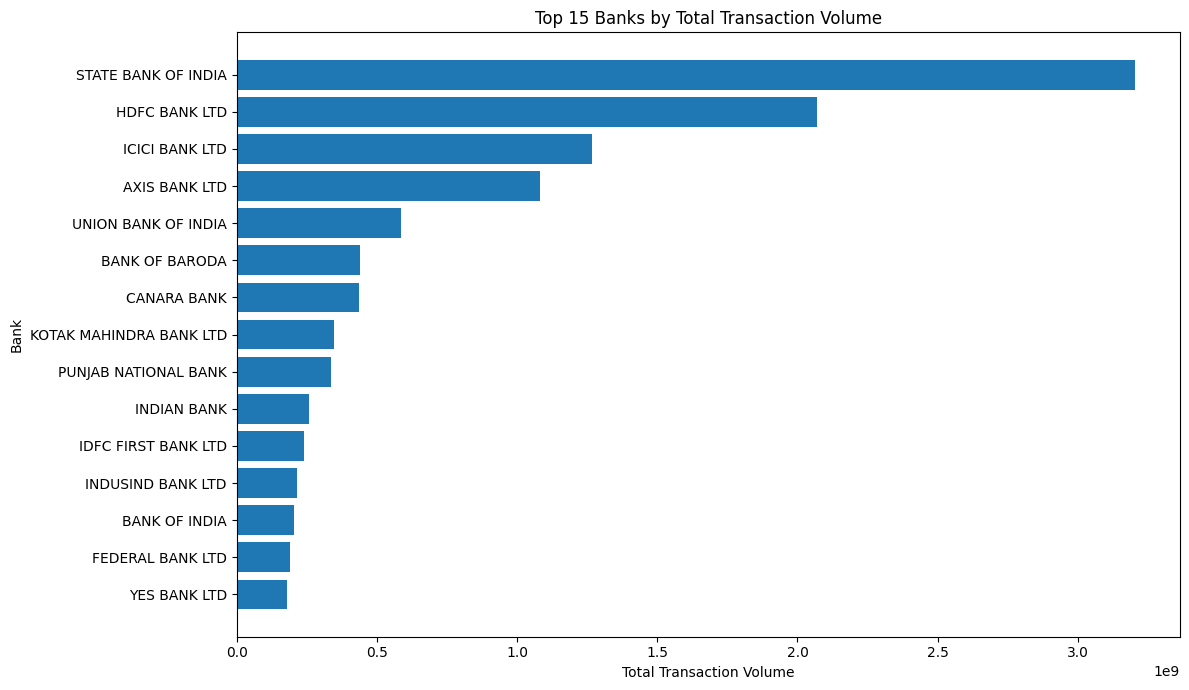


✓ Bank-wise transaction analysis completed.


In [51]:
# ============================================================================
# BANK-WISE TRANSACTION ANALYSIS
# ============================================================================

print("=" * 90)
print("BANK-WISE TRANSACTION ANALYSIS")
print("=" * 90)

# --------------------------------------------------------------------------
# Transaction volume columns
# --------------------------------------------------------------------------

volume_columns = [
    'Credit Card - Card Payments - PoS - Volume (in actuals)',
    'Credit Card - Card Payments - Online (e-com) - Volume (in actuals)',
    'Credit Card - Cash Withdrawal - ATM - Volume (in actuals)',
    'Debit Card - Card Payments - PoS - Volume (in actuals)',
    'Debit Card - Card Payments - Online (e-com) - Volume (in actuals)',
    'Debit Card - Cash Withdrawal - ATM - Volume (in actuals)'
]

# --------------------------------------------------------------------------
# Aggregate transaction volume by bank
# --------------------------------------------------------------------------

bank_volume = df.groupby(
    ['Bank Name', 'Bank Category']
)[volume_columns].sum()

# Total transaction volume
bank_volume['Total Transaction Volume'] = bank_volume.sum(axis=1)

# Sort descending
bank_volume = bank_volume.sort_values(
    'Total Transaction Volume',
    ascending=False
)

print("\nTOP 15 BANKS BY TOTAL TRANSACTION VOLUME")
print("-" * 90)

top_15_banks = bank_volume.head(15)

print(
    top_15_banks[
        ['Total Transaction Volume']
    ].to_string()
)

# --------------------------------------------------------------------------
# Bottom 15 banks
# --------------------------------------------------------------------------

print("\nBOTTOM 15 BANKS BY TOTAL TRANSACTION VOLUME")
print("-" * 90)

bottom_15_banks = bank_volume.tail(15).sort_values(
    'Total Transaction Volume'
)

print(
    bottom_15_banks[
        ['Total Transaction Volume']
    ].to_string()
)

# --------------------------------------------------------------------------
# Transaction volume share
# --------------------------------------------------------------------------

bank_volume['Volume Share (%)'] = (
    bank_volume['Total Transaction Volume']
    / bank_volume['Total Transaction Volume'].sum()
) * 100

print("\nTOP 10 BANKS — MARKET SHARE BY TRANSACTION VOLUME")
print("-" * 90)

print(
    bank_volume[
        ['Total Transaction Volume', 'Volume Share (%)']
    ].head(10).to_string()
)

# --------------------------------------------------------------------------
# Highest and lowest bank
# --------------------------------------------------------------------------

highest_bank = bank_volume.index[0]
highest_bank_volume = bank_volume.iloc[0]['Total Transaction Volume']

lowest_bank = bank_volume.index[-1]
lowest_bank_volume = bank_volume.iloc[-1]['Total Transaction Volume']

print("\nBANK-WISE INSIGHTS")
print("-" * 90)

print(f"Highest transaction-volume bank : {highest_bank[0]}")
print(f"Bank category                  : {highest_bank[1]}")
print(f"Total transaction volume       : {highest_bank_volume:,.0f}")

print(f"\nLowest transaction-volume bank  : {lowest_bank[0]}")
print(f"Bank category                  : {lowest_bank[1]}")
print(f"Total transaction volume       : {lowest_bank_volume:,.0f}")

# --------------------------------------------------------------------------
# Visualization — Top 15 banks
# --------------------------------------------------------------------------

import matplotlib.pyplot as plt

plot_data = top_15_banks[
    'Total Transaction Volume'
].sort_values()

plt.figure(figsize=(12, 7))

plt.barh(
    plot_data.index.get_level_values('Bank Name'),
    plot_data.values
)

plt.title("Top 15 Banks by Total Transaction Volume")
plt.xlabel("Total Transaction Volume")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()

print("\n✓ Bank-wise transaction analysis completed.")

TRANSACTION CHANNEL ANALYSIS

TOTAL TRANSACTION VOLUME BY CHANNEL
------------------------------------------------------------------------------------------
Debit Card - ATM Withdrawal         : 5,471,153,661
Credit Card - PoS                   : 2,868,395,345
Credit Card - Online                : 2,813,074,212
Debit Card - PoS                    : 999,971,898
Debit Card - Online                 : 334,588,609
Credit Card - ATM Withdrawal        : 8,274,309

CHANNEL SHARE
------------------------------------------------------------------------------------------
Debit Card - ATM Withdrawal         : 43.79%
Credit Card - PoS                   : 22.96%
Credit Card - Online                : 22.51%
Debit Card - PoS                    : 8.00%
Debit Card - Online                 : 2.68%
Credit Card - ATM Withdrawal        : 0.07%


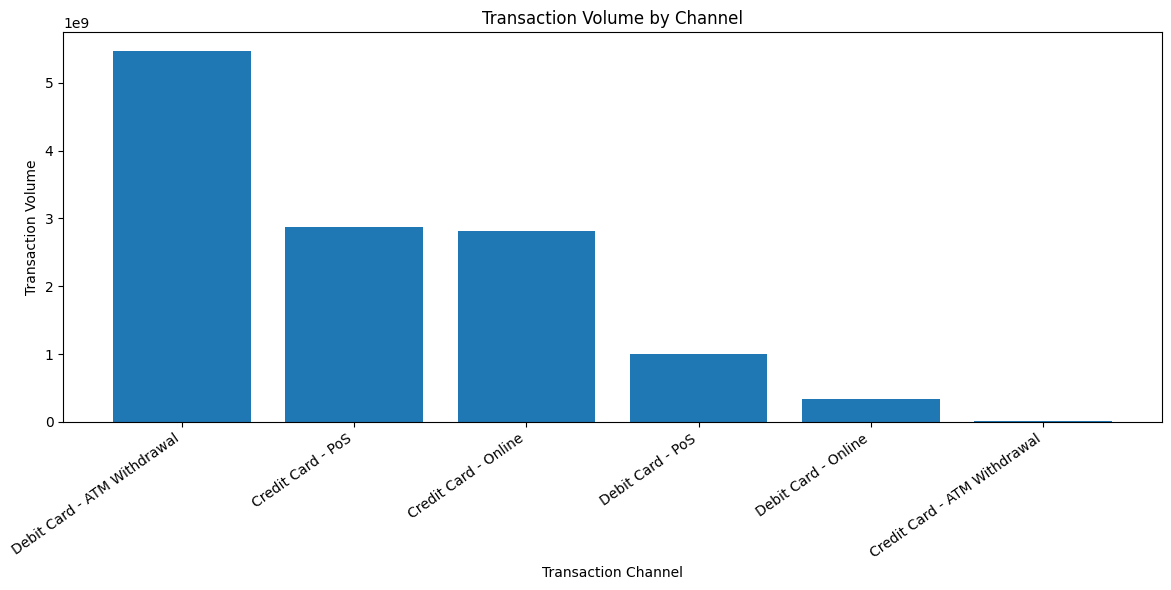


✓ Transaction channel analysis completed.


In [52]:
# ============================================================================
# TRANSACTION CHANNEL ANALYSIS
# ============================================================================

print("=" * 90)
print("TRANSACTION CHANNEL ANALYSIS")
print("=" * 90)

# --------------------------------------------------------------------------
# Define transaction channels
# --------------------------------------------------------------------------

channel_columns = {
    'Credit Card - PoS': 
        'Credit Card - Card Payments - PoS - Volume (in actuals)',

    'Credit Card - Online':
        'Credit Card - Card Payments - Online (e-com) - Volume (in actuals)',

    'Credit Card - ATM Withdrawal':
        'Credit Card - Cash Withdrawal - ATM - Volume (in actuals)',

    'Debit Card - PoS':
        'Debit Card - Card Payments - PoS - Volume (in actuals)',

    'Debit Card - Online':
        'Debit Card - Card Payments - Online (e-com) - Volume (in actuals)',

    'Debit Card - ATM Withdrawal':
        'Debit Card - Cash Withdrawal - ATM - Volume (in actuals)'
}

# --------------------------------------------------------------------------
# Calculate total volume for each channel
# --------------------------------------------------------------------------

channel_totals = {}

for channel, column in channel_columns.items():
    channel_totals[channel] = df[column].sum()

channel_summary = pd.Series(channel_totals).sort_values(ascending=False)

print("\nTOTAL TRANSACTION VOLUME BY CHANNEL")
print("-" * 90)

for channel, value in channel_summary.items():
    print(f"{channel:<35} : {value:,.0f}")

# --------------------------------------------------------------------------
# Percentage share
# --------------------------------------------------------------------------

channel_share = (
    channel_summary / channel_summary.sum()
) * 100

print("\nCHANNEL SHARE")
print("-" * 90)

for channel, share in channel_share.items():
    print(f"{channel:<35} : {share:.2f}%")

# --------------------------------------------------------------------------
# Visualization
# --------------------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    channel_summary.index,
    channel_summary.values
)

plt.title("Transaction Volume by Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Transaction Volume")
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print("\n✓ Transaction channel analysis completed.")